# SD3.5 CityPersons Pedestrian-Insertion Img2Img Augmentation Pipeline With Comparison Pairs
 
 Copy of the CityPersons augmentation notebook. This version keeps generated augmented images and also saves side-by-side original/augmented review pairs under `/kaggle/working/sd35_citypersons_augmented/comparison_pairs/`.


## 1. Install Dependencies

Keep Kaggle's preinstalled CUDA/PyTorch stack intact. Do not reinstall `torch`, `torchvision`, or `xformers`, because that can trigger CUDA, RAPIDS, `numba`, and `cuda-core` dependency conflicts.

In [14]:
!pip install -q \
  "diffusers>=0.30.0,<1.0.0" \
  "transformers>=4.40.0" \
  "peft>=0.11.0" \
  "accelerate>=0.30.0" \
  "bitsandbytes>=0.43.0" \
  sentencepiece protobuf safetensors \
  ultralytics

## 2. Runtime Check

In [15]:
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda runtime:", torch.version.cuda)
    print("gpu count:", torch.cuda.device_count())
    for index in range(torch.cuda.device_count()):
        print(f"gpu {index}:", torch.cuda.get_device_name(index))

torch: 2.10.0+cu128
cuda available: True
cuda runtime: 12.8
gpu count: 2
gpu 0: Tesla T4
gpu 1: Tesla T4


## 3. Hugging Face Login

In [16]:
from huggingface_hub import login

try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    login(token=hf_token)
    print("Logged in to Hugging Face with Kaggle secret HF_TOKEN.")
except Exception as exc:
    print("HF login skipped or failed. Add Kaggle secret HF_TOKEN if the model is gated.")
    print(type(exc).__name__, exc)

Logged in to Hugging Face with Kaggle secret HF_TOKEN.


## 4. Configuration

Mount your Kaggle dataset and set `DATASET_ROOT` to the CityPersons folder. Architecture is kept the same as the previous SD3.5 notebook; only dataset and augmentation task are changed.


In [17]:
from pathlib import Path

DATASET_ROOT_CANDIDATES = [
    Path("/kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir"),
    Path("/kaggle/input/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir"),
    Path("/kaggle/input/citypersons-dataset-with-bg-image"),
    Path("/kaggle/input/datasets/samyamine23/cityperson"),
    Path("/kaggle/input/cityperson"),
    Path("/kaggle/input/citypersons"),
    Path("/kaggle/input/city-persons"),
    Path("/kaggle/input/city-persons-2-0"),
    Path("/kaggle/input/city-persons-20"),
    Path("/kaggle/input/dataset"),
    Path("Dataset"),
]


def looks_like_roboflow_citypersons_root(path):
    path = Path(path)
    return (
        (path / "train" / "images").exists()
        and ((path / "valid" / "images").exists() or (path / "val" / "images").exists())
    )


def resolve_dataset_root(candidates):
    for path in candidates:
        if looks_like_roboflow_citypersons_root(path):
            return Path(path)
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in sorted(kaggle_input.rglob("data.yaml")):
            root = path.parent
            if looks_like_roboflow_citypersons_root(root):
                return root
    return next((Path(path) for path in candidates if Path(path).exists()), Path(candidates[0]))


DATASET_ROOT = resolve_dataset_root(DATASET_ROOT_CANDIDATES)
VALID_SPLIT_NAME = "valid" if (DATASET_ROOT / "valid" / "images").exists() else "val"
IMAGE_ROOT = DATASET_ROOT
LABEL_ROOT = DATASET_ROOT
DATASET_SPLIT_DIRS = {
    "train": DATASET_ROOT / "train" / "images",
    "val": DATASET_ROOT / VALID_SPLIT_NAME / "images",
}
LABEL_SPLIT_DIRS = {
    "train": DATASET_ROOT / "train" / "labels",
    "val": DATASET_ROOT / VALID_SPLIT_NAME / "labels",
}
SCENE_BUCKETS = ["urban_pedestrian_scene"]
IMAGE_SUBDIR = "images"
CAPTION_CSV = None  # Optional CSV with columns: file_name, caption

MODEL_BACKEND = "sd35"  # "sd35" target or "sdxl" baseline
SD35_MODEL_ID = "stabilityai/stable-diffusion-3.5-medium"
SDXL_MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

OUTPUT_DIR = Path("/kaggle/working/sd35_citypersons_augmented")
LORA_DIR = Path("/kaggle/working/sd35-lora-output")
LOG_DIR = Path("/kaggle/working/training_logs")
TRAIN_LOG_PATH = LOG_DIR / "train_log.csv"
TRAIN_CURVE_PATH = LOG_DIR / "train_loss_curve.png"
METRICS_DIR = Path("/kaggle/working/metrics")
METRICS_CSV_PATH = METRICS_DIR / "augmentation_metrics.csv"
METRICS_SUMMARY_PATH = METRICS_DIR / "augmentation_metrics_summary.csv"
METRICS_PLOT_PATH = METRICS_DIR / "augmentation_metrics_by_variant.png"
PATCH_DEBUG_DIR = OUTPUT_DIR / "patch_debug"
RESOLUTION = 448  # 512 can OOM on Kaggle T4 x2 with SD3.5 Medium; use 512 only if VRAM allows
LORA_RANK = 16  # use 8 if OOM
TRAIN_BATCH_SIZE = 1
MAX_TRAIN_IMAGES = 500  # fast smoke-test scan; set None only when you really need all images
MAX_TRAIN_STEPS = 300
LEARNING_RATE = 1e-4
USE_T5 = False  # False is safer on Kaggle T4
TRAIN_DEVICE = "cuda:0"
USE_ALL_GPUS_FOR_AUGMENTATION = True
AUGMENTATION_DEVICES = None  # None = auto-detect all CUDA GPUs, e.g. ["cuda:0", "cuda:1"] on Kaggle T4 x2
USE_MODEL_CPU_OFFLOAD = True  # lower VRAM for SD3.5 Medium on T4; slower but much safer
MATCH_LABEL_JSON = False
BACKGROUND_PRESERVATION_MODE = "context_person_composite"  # V3: generate on a context crop, segment the new person, paste only person pixels onto original
PATCH_CONTEXT_RATIO = 0.18
PATCH_MIN_SIZE = 128
PATCH_FEATHER_RADIUS = 3
PATCH_MAX_PLACEMENT_TRIES = 180
PATCH_ROAD_Y_RANGE = (0.66, 0.92)
PERSPECTIVE_SCALE_NEAR = 1.05
PERSPECTIVE_SCALE_FAR = 0.34
USE_REFERENCE_PERSON_SCALE = True
REFERENCE_SCALE_MIN_PERSON_HEIGHT = 24
REFERENCE_SCALE_MAX_PERSON_HEIGHT = 180
REFERENCE_SCALE_BLEND = 0.48
REFERENCE_SCALE_MAX_Y_DISTANCE = 70
CAR_HEIGHT_TO_PERSON_HEIGHT_RATIO = 0.75
CAR_REFERENCE_SCALE_BLEND = 0.38
CAR_REFERENCE_MAX_Y_DISTANCE = 90
CAR_REFERENCE_MIN_HEIGHT = 18
CAR_REFERENCE_MAX_HEIGHT = 130
REFERENCE_SCALE_MIN_FACTOR = 0.70
REFERENCE_SCALE_MAX_FACTOR = 1.28
REFERENCE_SCALE_MIN_SAMPLES = 2
REFERENCE_SCALE_MIN_Y_GAP = 24
REFERENCE_SCALE_MIN_SLOPE = 0.06
REFERENCE_SCALE_MAX_SLOPE = 1.10
PERSON_ASPECT_RATIO = 0.36
REJECT_IF_MASK_TOUCHES_BORDER = True
PERSON_BORDER_REJECT_PIXELS = 6
INSERTION_EDGE_MARGIN = 16
INSERTION_OVERLAP_PENALTY = 3.0
INSERTION_CENTER_BIAS = 0.00
PLACEMENT_SLOT_BIAS = 1.15
PLACEMENT_SLOT_XS = (0.20, 0.36, 0.52, 0.68, 0.82)
PLACEMENT_SLOT_YS = (0.68, 0.74, 0.80, 0.86, 0.91)
PLACEMENT_SLOT_JITTER = 0.10
SMART_PLACEMENT_VERSION = "v2"
USE_SEMANTIC_PLACEMENT = True  # Semantic Placement V2: prefer road/sidewalk/terrain slots before generation
SEMANTIC_SEGMENTATION_MODEL_ID = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
VALID_PLACEMENT_LABELS = {"road", "sidewalk", "terrain"}
AVOID_PLACEMENT_LABELS = {"person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle", "building", "wall", "fence", "pole", "traffic light", "traffic sign", "sky"}
MIN_FOOT_SUPPORT = 0.35
SEMANTIC_FOOT_WEIGHT = 5.0
SEMANTIC_AVOID_PENALTY = 7.0
PATCH_PERSON_CLASS_IDS = {0}  # Roboflow/YOLO person class id
PATCH_VEHICLE_CLASS_IDS = {2, 5, 7}  # COCO/YOLO car, bus, truck ids when vehicle labels are available
HUMAN_MASK_PADDING = 10
HUMAN_MASK_BLUR_RADIUS = 2
BBOX_MASK_PADDING = 8
BBOX_MASK_BLUR_RADIUS = 3
BBOX_MASK_RADIUS = 8
FLEXIBLE_SCALE_INPAINT = True
SCALE_ENVELOPE_HEIGHT_MULT = 1.18
SCALE_ENVELOPE_WIDTH_MULT = 1.34
GROUP_PERSON_GAP_RATIO = 0.10
GROUP_PERSON_HEIGHT_JITTER = 0.10
CONTACT_SHADOW_ENABLED = True
CONTACT_SHADOW_OPACITY_NEAR = 46
CONTACT_SHADOW_OPACITY_FAR = 16
DRAW_INSERTION_GUIDE = False  # paint a faint human guide before img2img so SD3.5 adds a pedestrian
INSERTION_GUIDE_ALPHA = 0.0
INSERTION_GUIDE_BLUR = 0.0
SAVE_PATCH_DEBUG = True
PATCH_DEBUG_MAX_ITEMS = 24
CONTEXT_CROP_EXPAND = 3.0
CONTEXT_CROP_MIN_SIZE = 192
CONTEXT_INPAINT_MASK_PADDING = 56
CONTEXT_PERSON_SEGMENTATION_MODEL = "yolov8n-seg.pt"
CONTEXT_PERSON_MIN_CONFIDENCE = 0.12
MIN_RETRY_PERSON_CONFIDENCE = 0.45
MIN_GHOST_PERSON_MASK_AREA_RATIO = 0.002
MIN_GHOST_PERSON_CONTRAST_255 = 12.0
CONTEXT_PERSON_MASK_THRESHOLD = 0.32
MIN_PERSON_DET_TARGET_HEIGHT_RATIO = 0.62
MAX_PERSON_TOP_OFFSET_RATIO = 0.42
MAX_PERSON_BOTTOM_GAP_RATIO = 0.30
MIN_PERSON_MASK_DET_HEIGHT_RATIO = 0.72
MIN_PERSON_MASK_TARGET_HEIGHT_RATIO = 0.55
MIN_PERSON_MASK_VERTICAL_BAND_COVERAGE = 0.24
MIN_PERSON_MASK_ASPECT_RATIO = 1.35
MAX_PERSON_MASK_ASPECT_RATIO = 5.2
CONTEXT_PERSON_FALLBACK_TO_BBOX_INPAINT = False  # during smoke tests, reject unchanged/undetected samples instead of saving weak bbox fallback
CONTEXT_GENERATION_RETRIES = 2
CONTEXT_MIN_GENERATED_MASK_DIFF = 0.035  # stricter: reject attempts where SD3.5 leaves the masked target almost unchanged
CONTEXT_MIN_PERSON_TARGET_OVERLAP = 0.12  # reject YOLO detections that are likely old people outside the insertion target
CONTEXT_MIN_PERSON_MASK_AREA_RATIO = 0.0012  # reject tiny/ghost masks; measured on the generated crop
CONTEXT_MIN_FINAL_PERSON_DIFF = 0.018  # reject composites whose pasted pixels are still nearly identical to source
COLOR_MATCH_PERSON_TO_SCENE = True
COLOR_MATCH_STRENGTH = 0.72  # blend generated person colors toward nearby source lighting
COLOR_MATCH_CONTEXT_PAD = 18
CONTEXT_TARGET_BBOX_EXPAND_FOR_DETECTION = 1.50

AUGMENTATION_VARIANTS = [
    "add_single_pedestrian",
    "add_two_pedestrians",
    "add_small_group",
    "add_occluded_pedestrian",
    "add_distant_pedestrian",
    "add_near_pedestrian",
]
AUGMENTATIONS_PER_BUCKET = 200
TARGET_SPLITS = ["train", "val"]  # dataset has train + valid only; valid is mapped to val
AUGMENTATION_STRENGTH = 0.72
GUIDANCE_SCALE = 7.2
NUM_INFERENCE_STEPS = 36
AUGMENTATION_VARIANT_WEIGHTS = {
    "add_single_pedestrian": 0.24,
    "add_two_pedestrians": 0.18,
    "add_small_group": 0.16,
    "add_occluded_pedestrian": 0.18,
    "add_distant_pedestrian": 0.14,
    "add_near_pedestrian": 0.10,
}
VARIANT_STRENGTHS = {
    "add_single_pedestrian": 0.72,
    "add_two_pedestrians": 0.74,
    "add_small_group": 0.76,
    "add_occluded_pedestrian": 0.74,
    "add_distant_pedestrian": 0.68,
    "add_near_pedestrian": 0.76,
}
VARIANT_GUIDANCE_SCALES = {
    "add_single_pedestrian": 7.2,
    "add_two_pedestrians": 7.0,
    "add_small_group": 7.1,
    "add_occluded_pedestrian": 7.0,
    "add_distant_pedestrian": 6.6,
    "add_near_pedestrian": 7.3,
}
VARIANT_NUM_INFERENCE_STEPS = {
    "add_single_pedestrian": 36,
    "add_two_pedestrians": 36,
    "add_small_group": 38,
    "add_occluded_pedestrian": 36,
    "add_distant_pedestrian": 34,
    "add_near_pedestrian": 38,
}
SEED = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LORA_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PATCH_DEBUG_DIR.mkdir(parents=True, exist_ok=True)


## 5. Imports And Prompt Templates

In [18]:
import csv
import gc
import json
import math
import numpy as np
import os
import random
import statistics
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from threading import Lock
from typing import Optional

os.environ["DIFFUSERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore", message="Flax classes are deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="diffusers.*")

import bitsandbytes as bnb
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from diffusers import (
    StableDiffusion3Img2ImgPipeline,
    StableDiffusion3Pipeline,
    StableDiffusionXLImg2ImgPipeline,
)
from diffusers.utils import logging as diffusers_logging
from diffusers.models.attention_processor import AttnProcessor2_0
from peft import LoraConfig, get_peft_model
from PIL import Image, ImageOps, ImageDraw, ImageFilter, ImageChops

diffusers_logging.set_verbosity_error()

try:
    from diffusers import StableDiffusion3InpaintPipeline, StableDiffusionXLInpaintPipeline
except ImportError:
    StableDiffusion3InpaintPipeline = None
    StableDiffusionXLInpaintPipeline = None

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
BASE_CAPTION = "photorealistic urban street scene, fixed traffic camera"
PRESERVATION_PROMPT = (
    "must add a new clearly visible realistic full-body pedestrian in the masked area, "
    "standing on road or sidewalk, feet touching ground, natural clothing, correct perspective and scale, "
    "do not leave the mask empty, preserve unmasked background"
)

SCENE_PROMPTS = {
    "urban_pedestrian_scene": "realistic urban pedestrian street scene",
}

VARIANT_PROMPTS = {
    "add_single_pedestrian": "add exactly one new pedestrian, visible head torso legs",
    "add_two_pedestrians": "add exactly two new pedestrians, both visible",
    "add_small_group": "add a small group of three pedestrians, visible bodies",
    "add_occluded_pedestrian": "add one new partly occluded pedestrian, still recognizable",
    "add_distant_pedestrian": "add one distant but clearly visible full-body pedestrian, not tiny, visible silhouette and legs",
    "add_near_pedestrian": "add one near foreground pedestrian, clear full body, about 1.5x larger than a normal mid-ground pedestrian"
}

NEGATIVE_PROMPT = (
    "empty mask, unchanged image, empty street, invisible person, missing person, ghost person, faint silhouette, "
    "partial body, cropped body, wrong scale, floating, bad anatomy, extra limbs, background change, hard seam, watermark"
)
PIPELINE_LOAD_LOCK = Lock()
SEMANTIC_SEGMENTER = None
SEMANTIC_MASK_CACHE = {}
PERSON_SEGMENTER = None





## 6. Dataset Scanner

This scans CityPersons image files from the mounted Kaggle folder. The `ImageRecord` contract is kept the same as the old notebook so downstream training/augmentation functions keep the same architecture.


In [19]:
@dataclass
class ImageRecord:
    path: Path
    split: str
    bucket: str
    caption: str
    label_path: Optional[Path] = None
    weather: Optional[str] = None
    timeofday: Optional[str] = None
    scene: Optional[str] = None


def load_caption_map(csv_path):
    if not csv_path:
        return {}
    csv_path = Path(csv_path)
    if not csv_path.exists():
        print(f"Caption CSV not found: {csv_path}. Using default captions.")
        return {}
    caption_map = {}
    with csv_path.open("r", encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            file_name = row.get("file_name") or row.get("filename") or row.get("image")
            caption = row.get("caption") or row.get("prompt")
            if file_name and caption:
                caption_map[Path(file_name).name] = caption
    return caption_map


def infer_split(path):
    parts = [part.lower() for part in Path(path).parts]
    if "train" in parts:
        return "train"
    if "valid" in parts or "val" in parts:
        return "val"
    if "test" in parts:
        return "test"
    return "train"


def find_label_path(image_path, label_dir=None):
    image_path = Path(image_path)
    split = infer_split(image_path)
    split_label_dir = LABEL_SPLIT_DIRS.get(split)
    sibling_label_dir = image_path.parent.parent / "labels" if image_path.parent.name == "images" else None
    candidates = [
        image_path.with_suffix(".json"),
        image_path.parent / f"{image_path.stem}.json",
        image_path.parent / f"{image_path.stem}.txt",
        sibling_label_dir / f"{image_path.stem}.txt" if sibling_label_dir else None,
        sibling_label_dir / f"{image_path.stem}.json" if sibling_label_dir else None,
        split_label_dir / f"{image_path.stem}.txt" if split_label_dir else None,
        split_label_dir / f"{image_path.stem}.json" if split_label_dir else None,
        image_path.parent / f"{image_path.stem}_gtBboxCityPersons.json",
        image_path.parent / f"{image_path.stem}_gtFine_polygons.json",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate
    return None


def build_caption(path, bucket, caption_map, metadata=None, include_weather=True):
    if Path(path).name in caption_map:
        return caption_map[Path(path).name]
    return BASE_CAPTION


def build_generation_prompt(record, variant):
    variant_prompt = VARIANT_PROMPTS[variant]
    return (
        f"{record.caption}, {variant_prompt}, "
        f"{PRESERVATION_PROMPT}"
    )


def build_variant_negative_prompt(variant):
    return NEGATIVE_PROMPT


def is_source_image(path):
    path = Path(path)
    if path.suffix.lower() not in IMAGE_EXTS:
        return False
    name = path.name.lower()
    if any(token in name for token in ["mask", "label", "gtfine", "gtbbox", "instance", "polygon", "color"]):
        return False
    return True


def list_image_paths_fast(split_dir, max_images=None):
    split_dir = Path(split_dir)
    if not split_dir.exists():
        return []
    paths = []
    for path in sorted(split_dir.rglob("*")):
        if path.is_file() and is_source_image(path):
            paths.append(path)
            if max_images and len(paths) >= max_images:
                break
    return paths


def scan_dataset(split_dirs=DATASET_SPLIT_DIRS, caption_csv=CAPTION_CSV, max_images=MAX_TRAIN_IMAGES):
    caption_map = load_caption_map(caption_csv)
    records = []
    found_split_images = False
    for split, split_dir in split_dirs.items():
        image_paths = list_image_paths_fast(split_dir, max_images=None)
        if image_paths:
            found_split_images = True
        for image_path in image_paths:
            records.append(ImageRecord(
                path=image_path,
                split=split,
                bucket="urban_pedestrian_scene",
                caption=build_caption(image_path, "urban_pedestrian_scene", caption_map),
                label_path=find_label_path(image_path),
                weather=None,
                timeofday=None,
                scene="urban",
            ))
            if max_images and len(records) >= max_images:
                return records

    if not found_split_images:
        for image_path in sorted(DATASET_ROOT.rglob("*")):
            if not image_path.is_file() or not is_source_image(image_path):
                continue
            records.append(ImageRecord(
                path=image_path,
                split=infer_split(image_path),
                bucket="urban_pedestrian_scene",
                caption=build_caption(image_path, "urban_pedestrian_scene", caption_map),
                label_path=find_label_path(image_path),
                weather=None,
                timeofday=None,
                scene="urban",
            ))
            if max_images and len(records) >= max_images:
                break
    return records


records = scan_dataset()
print(f"Scanned {len(records)} CityPersons images from {DATASET_ROOT}")
if not records:
    print("No images found. Check DATASET_ROOT and Kaggle dataset mount.")
else:
    split_counts = {}
    for record in records:
        split_counts[record.split] = split_counts.get(record.split, 0) + 1
    print("split counts:", split_counts)
    for record in records[:10]:
        print(record.split, record.bucket, record.path)


Scanned 500 CityPersons images from /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir
split counts: {'train': 500}
train urban_pedestrian_scene /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir/train/images/aachen_000000_000019_leftImg8bit.png
train urban_pedestrian_scene /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir/train/images/aachen_000002_000019_leftImg8bit.png
train urban_pedestrian_scene /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir/train/images/aachen_000003_000019_leftImg8bit.png
train urban_pedestrian_scene /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir/train/images/aachen_000004_000019_leftImg8bit.png
train urban_pedestrian_scene /kaggle/input/datasets/muttahirulislam/citypersons-dataset-with-bg-image/yolo_dir/yolo_dir/train/images/aachen_000005_000019_leftImg8bi

In [20]:
def summarize_citypersons_records(records):
    split_counts = {}
    for record in records:
        split_counts[record.split] = split_counts.get(record.split, 0) + 1
    print("CityPersons split counts:", split_counts)
    print("scene buckets:", sorted({record.bucket for record in records}))


summarize_citypersons_records(records)


CityPersons split counts: {'train': 500}
scene buckets: ['urban_pedestrian_scene']


In [21]:
def preview_prompt_samples(records, variants=("add_single_pedestrian", "add_two_pedestrians", "add_occluded_pedestrian", "add_distant_pedestrian"), n=3):
    for record in records[:n]:
        print("\nimage:", record.path.name)
        print("label:", {"weather": record.weather, "timeofday": record.timeofday, "scene": record.scene})
        print("train caption:", record.caption)
        for variant in variants:
            print(f"{variant} prompt:", build_generation_prompt(record, variant))


preview_prompt_samples(records)



image: aachen_000000_000019_leftImg8bit.png
label: {'weather': None, 'timeofday': None, 'scene': 'urban'}
train caption: CityPersons urban street scene, fixed camera, preserved road geometry
add_single_pedestrian prompt: CityPersons urban street scene, fixed camera, preserved road geometry, add one realistic pedestrian, correct scale, grounded, photorealistic street scene, preserve background and vehicles
add_two_pedestrians prompt: CityPersons urban street scene, fixed camera, preserved road geometry, add two realistic pedestrians, correct scale, grounded, photorealistic street scene, preserve background and vehicles
add_occluded_pedestrian prompt: CityPersons urban street scene, fixed camera, preserved road geometry, add one partially occluded pedestrian, correct scale, photorealistic street scene, preserve background and vehicles
add_distant_pedestrian prompt: CityPersons urban street scene, fixed camera, preserved road geometry, add one small distant pedestrian, correct perspectiv

## 7. Dataset Preview

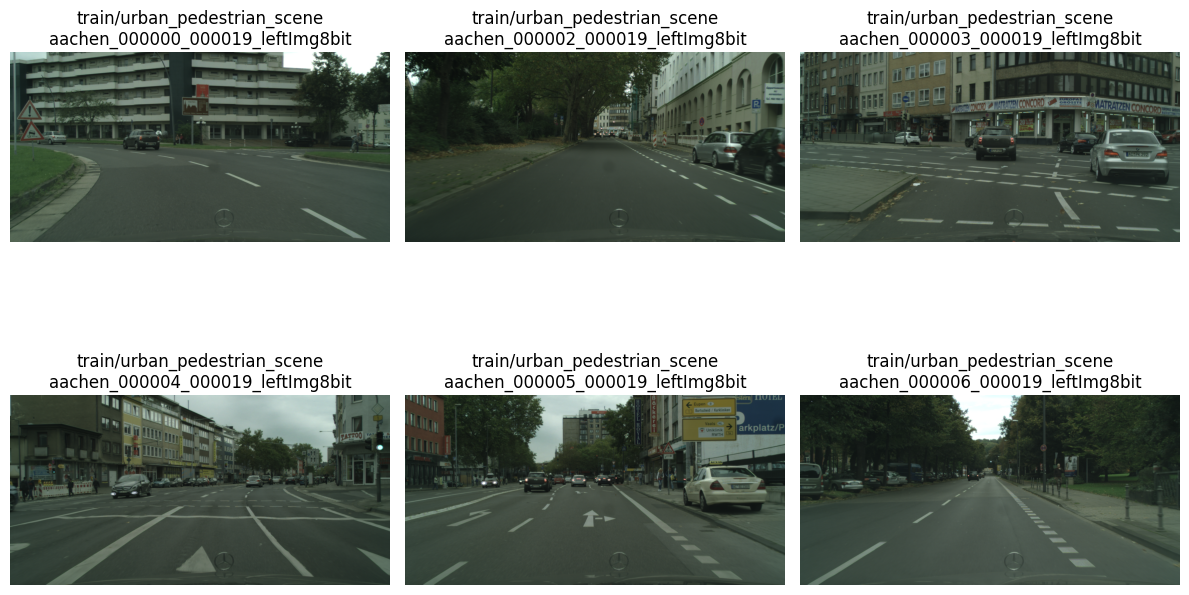

In [22]:
def preview_records(records, n=6):
    if not records:
        print("No dataset records to preview yet.")
        return
    sample = records[:n]
    cols = min(3, len(sample))
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, record in enumerate(sample, 1):
        image = Image.open(record.path).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(image)
        plt.title(f"{record.split}/{record.bucket}\n{record.path.name[:32]}")
        plt.axis("off")
    plt.tight_layout()


preview_records(records)

## 8. Image Preprocessing

In [23]:
def load_source_image(path):
    return ImageOps.exif_transpose(Image.open(path)).convert("RGB")


def resize_center_crop(image, resolution=RESOLUTION):
    width, height = image.size
    scale = resolution / min(width, height)
    new_size = (round(width * scale), round(height * scale))
    image = image.resize(new_size, Image.BICUBIC)
    left = (image.width - resolution) // 2
    top = (image.height - resolution) // 2
    return image.crop((left, top, left + resolution, top + resolution))


def image_to_tensor(image, resolution=RESOLUTION, device="cuda", dtype=torch.float16):
    image = resize_center_crop(image, resolution)
    pixel_values = torch.tensor(list(image.getdata()), dtype=torch.float32).view(resolution, resolution, 3)
    pixel_values = pixel_values.permute(2, 0, 1).unsqueeze(0) / 127.5 - 1.0
    return pixel_values.to(device=device, dtype=dtype)


def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 9. SD3.5 LoRA Training Across Dataset

This trains LoRA over multiple images from `records`. Keep `TRAIN_BATCH_SIZE=1` on T4. Start with small `MAX_TRAIN_STEPS` to validate memory.

In [24]:
def append_train_log(row, log_path=TRAIN_LOG_PATH):
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "step", "max_steps", "loss", "image", "split", "bucket", "weather",
        "timeofday", "scene", "rank", "resolution", "learning_rate", "elapsed_sec"
    ]
    write_header = not log_path.exists()
    with log_path.open("a", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        if write_header:
            writer.writeheader()
        writer.writerow(row)


def plot_train_curve(log_path=TRAIN_LOG_PATH, output_path=TRAIN_CURVE_PATH, window=10):
    log_path = Path(log_path)
    if not log_path.exists():
        print(f"Train log not found: {log_path}")
        return None

    steps, losses = [], []
    with log_path.open("r", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            steps.append(int(row["step"]))
            losses.append(float(row["loss"]))

    if not steps:
        print("Train log is empty.")
        return None

    moving = []
    for idx in range(len(losses)):
        start = max(0, idx - window + 1)
        moving.append(sum(losses[start:idx + 1]) / (idx - start + 1))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, losses, alpha=0.35, label="loss")
    plt.plot(steps, moving, linewidth=2, label=f"moving avg ({window})")
    plt.xlabel("step")
    plt.ylabel("MSE loss")
    plt.title("SD3.5 LoRA training loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    print(f"Saved training curve: {output_path}")
    return output_path


def get_sigmas(noise_scheduler, timesteps, n_dim, dtype, device):
    sigmas = noise_scheduler.sigmas.to(device=device, dtype=dtype)
    schedule_timesteps = noise_scheduler.timesteps.to(device)
    step_indices = []
    for timestep in timesteps:
        matches = (schedule_timesteps == timestep).nonzero()
        step_indices.append(matches[0].item() if len(matches) else 0)
    sigma = sigmas[step_indices].flatten()
    while len(sigma.shape) < n_dim:
        sigma = sigma.unsqueeze(-1)
    return sigma


def load_sd35_pipeline_for_training(model_id=SD35_MODEL_ID, use_t5=USE_T5):
    kwargs = {
        "torch_dtype": torch.float16,
        "use_safetensors": True,
    }
    if not use_t5:
        kwargs.update({"text_encoder_3": None, "tokenizer_3": None})
    try:
        return StableDiffusion3Pipeline.from_pretrained(model_id, **kwargs)
    except TypeError:
        kwargs.pop("text_encoder_3", None)
        kwargs.pop("tokenizer_3", None)
        return StableDiffusion3Pipeline.from_pretrained(model_id, **kwargs)


def train_sd35_lora_on_records(records, max_steps=MAX_TRAIN_STEPS, rank=LORA_RANK, log_path=TRAIN_LOG_PATH):
    if not records:
        raise FileNotFoundError("No images found. Mount dataset folder and rerun scan_dataset().")
    if TRAIN_BATCH_SIZE != 1:
        raise ValueError("Kaggle T4 path is configured for TRAIN_BATCH_SIZE=1.")

    log_path = Path(log_path)
    if log_path.exists():
        log_path.unlink()

    device = TRAIN_DEVICE
    start_time = time.time()
    pipe = load_sd35_pipeline_for_training()
    pipe.scheduler.set_timesteps(1000, device=device)

    pipe.vae.requires_grad_(False)
    pipe.text_encoder.requires_grad_(False)
    pipe.text_encoder_2.requires_grad_(False)
    if getattr(pipe, "text_encoder_3", None) is not None:
        pipe.text_encoder_3.requires_grad_(False)

    pipe.vae.to(device)
    pipe.text_encoder.to(device)
    pipe.text_encoder_2.to(device)
    if getattr(pipe, "text_encoder_3", None) is not None:
        pipe.text_encoder_3.to(device)
    pipe.transformer.to(device)
    pipe.transformer.set_attn_processor(AttnProcessor2_0())
    pipe.transformer.enable_gradient_checkpointing()

    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
        init_lora_weights="gaussian",
    )
    pipe.transformer = get_peft_model(pipe.transformer, lora_config)
    pipe.transformer.print_trainable_parameters()
    pipe.transformer.train()

    optimizer = bnb.optim.AdamW8bit(pipe.transformer.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    timesteps_schedule = pipe.scheduler.timesteps.to(device)

    for step in range(max_steps):
        record = records[step % len(records)]
        image = load_source_image(record.path)
        pixel_values = image_to_tensor(image, resolution=RESOLUTION, device=device, dtype=torch.float16)

        with torch.no_grad():
            latents = pipe.vae.encode(pixel_values).latent_dist.sample()
            scaling = getattr(pipe.vae.config, "scaling_factor", 1.0)
            shift = getattr(pipe.vae.config, "shift_factor", 0.0)
            latents = (latents - shift) * scaling

            prompt_embeds, _, pooled_prompt_embeds, _ = pipe.encode_prompt(
                prompt=record.caption,
                prompt_2=record.caption,
                prompt_3=record.caption if USE_T5 else None,
                device=device,
                num_images_per_prompt=1,
                do_classifier_free_guidance=False,
            )

        noise = torch.randn_like(latents)
        timestep_index = torch.randint(0, len(timesteps_schedule), (1,), device=device)
        timesteps = timesteps_schedule[timestep_index]
        sigmas = get_sigmas(pipe.scheduler, timesteps, latents.ndim, latents.dtype, device)
        noisy_latents = sigmas * noise + (1.0 - sigmas) * latents
        target = noise - latents

        model_pred = pipe.transformer(
            hidden_states=noisy_latents,
            timestep=timesteps,
            encoder_hidden_states=prompt_embeds,
            pooled_projections=pooled_prompt_embeds,
            return_dict=False,
        )[0]

        loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        loss_value = float(loss.item())
        append_train_log({
            "step": step + 1,
            "max_steps": max_steps,
            "loss": loss_value,
            "image": record.path.name,
            "split": record.split,
            "bucket": record.bucket,
            "weather": record.weather or "",
            "timeofday": record.timeofday or "",
            "scene": record.scene or "",
            "rank": rank,
            "resolution": RESOLUTION,
            "learning_rate": LEARNING_RATE,
            "elapsed_sec": round(time.time() - start_time, 3),
        }, log_path)

        if step == 0 or (step + 1) % 25 == 0:
            print(f"step {step + 1}/{max_steps} | loss={loss_value:.5f} | image={record.path.name}")

    LORA_DIR.mkdir(parents=True, exist_ok=True)
    pipe.transformer.save_pretrained(LORA_DIR / "transformer_peft")
    print(f"Saved PEFT transformer LoRA to {LORA_DIR / 'transformer_peft'}")
    print(f"Saved train log: {log_path}")
    plot_train_curve(log_path)
    return pipe


# Run when dataset is mounted:
# Optional: train a new LoRA adapter before augmentation.
# Leave this commented if you only want to generate images with base SD3.5 or an existing LoRA in LORA_DIR.
# trained_pipe = train_sd35_lora_on_records(records, max_steps=MAX_TRAIN_STEPS, rank=LORA_RANK)

## 10. Img2Img Augmentation Pipeline

In [25]:
def resolve_augmentation_devices():
    if AUGMENTATION_DEVICES:
        return AUGMENTATION_DEVICES
    if not torch.cuda.is_available():
        return ["cpu"]
    if USE_ALL_GPUS_FOR_AUGMENTATION:
        return [f"cuda:{index}" for index in range(torch.cuda.device_count())]
    return [TRAIN_DEVICE]


def build_img2img_pipeline(backend=MODEL_BACKEND, lora_dir=None, device=TRAIN_DEVICE):
    if backend == "sd35":
        pipeline_cls = StableDiffusion3Img2ImgPipeline
        model_id = SD35_MODEL_ID
        kwargs = {"torch_dtype": torch.float16, "use_safetensors": True, "low_cpu_mem_usage": True}
        if not USE_T5:
            kwargs.update({"text_encoder_3": None, "tokenizer_3": None})
    elif backend == "sdxl":
        pipeline_cls = StableDiffusionXLImg2ImgPipeline
        model_id = SDXL_MODEL_ID
        kwargs = {"torch_dtype": torch.float16, "use_safetensors": True, "low_cpu_mem_usage": True}
    else:
        raise ValueError(f"Unsupported backend: {backend}")

    if str(device).startswith("cuda"):
        torch.cuda.set_device(torch.device(device).index or 0)

    with PIPELINE_LOAD_LOCK:
        try:
            pipe = pipeline_cls.from_pretrained(model_id, **kwargs)
        except TypeError:
            kwargs.pop("text_encoder_3", None)
            kwargs.pop("tokenizer_3", None)
            kwargs.pop("low_cpu_mem_usage", None)
            pipe = pipeline_cls.from_pretrained(model_id, **kwargs)

        if lora_dir and Path(lora_dir).exists() and any(Path(lora_dir).iterdir()):
            lora_dir = Path(lora_dir)
            peft_dir = lora_dir / "transformer_peft"
            try:
                if peft_dir.exists() and hasattr(pipe.transformer, "load_adapter"):
                    pipe.transformer.load_adapter(str(peft_dir), adapter_name="citypersons_pedestrian_lora")
                    pipe.transformer.set_adapter("citypersons_pedestrian_lora")
                    print(f"Loaded PEFT transformer adapter from {peft_dir}")
                else:
                    pipe.load_lora_weights(str(lora_dir))
                    print(f"Loaded Diffusers LoRA from {lora_dir}")
            except Exception as exc:
                print("LoRA load skipped. The base model will be used for augmentation.")
                print(type(exc).__name__, exc)

        if str(device).startswith("cuda") and USE_MODEL_CPU_OFFLOAD and hasattr(pipe, "enable_model_cpu_offload"):
            gpu_id = torch.device(device).index or 0
            pipe.enable_model_cpu_offload(gpu_id=gpu_id)
            print(f"Enabled model CPU offload for {device}")
        else:
            pipe.to(device)
        if hasattr(pipe, "enable_vae_slicing"):
            pipe.enable_vae_slicing()
        if hasattr(pipe, "enable_vae_tiling"):
            pipe.enable_vae_tiling()
        if hasattr(pipe, "enable_attention_slicing"):
            pipe.enable_attention_slicing()
    return pipe


def build_inpaint_pipeline(backend=MODEL_BACKEND, lora_dir=None, device=TRAIN_DEVICE):
    if backend == "sd35":
        if StableDiffusion3InpaintPipeline is None:
            raise ImportError("StableDiffusion3InpaintPipeline is not available in this diffusers version.")
        pipeline_cls = StableDiffusion3InpaintPipeline
        model_id = SD35_MODEL_ID
        kwargs = {"torch_dtype": torch.float16, "use_safetensors": True, "low_cpu_mem_usage": True}
        if not USE_T5:
            kwargs.update({"text_encoder_3": None, "tokenizer_3": None})
    elif backend == "sdxl":
        if StableDiffusionXLInpaintPipeline is None:
            raise ImportError("StableDiffusionXLInpaintPipeline is not available in this diffusers version.")
        pipeline_cls = StableDiffusionXLInpaintPipeline
        model_id = SDXL_MODEL_ID
        kwargs = {"torch_dtype": torch.float16, "use_safetensors": True, "low_cpu_mem_usage": True}
    else:
        raise ValueError(f"Unsupported backend: {backend}")

    if str(device).startswith("cuda"):
        torch.cuda.set_device(torch.device(device).index or 0)

    with PIPELINE_LOAD_LOCK:
        try:
            pipe = pipeline_cls.from_pretrained(model_id, **kwargs)
        except TypeError:
            kwargs.pop("text_encoder_3", None)
            kwargs.pop("tokenizer_3", None)
            kwargs.pop("low_cpu_mem_usage", None)
            pipe = pipeline_cls.from_pretrained(model_id, **kwargs)

        if lora_dir and Path(lora_dir).exists() and any(Path(lora_dir).iterdir()):
            lora_dir = Path(lora_dir)
            peft_dir = lora_dir / "transformer_peft"
            try:
                if peft_dir.exists() and hasattr(pipe.transformer, "load_adapter"):
                    pipe.transformer.load_adapter(str(peft_dir), adapter_name="citypersons_pedestrian_lora")
                    pipe.transformer.set_adapter("citypersons_pedestrian_lora")
                    print(f"Loaded PEFT transformer adapter from {peft_dir}")
                else:
                    pipe.load_lora_weights(str(lora_dir))
                    print(f"Loaded Diffusers LoRA from {lora_dir}")
            except Exception as exc:
                print("LoRA load skipped. The base model will be used for inpainting.")
                print(type(exc).__name__, exc)

        if str(device).startswith("cuda") and USE_MODEL_CPU_OFFLOAD and hasattr(pipe, "enable_model_cpu_offload"):
            gpu_id = torch.device(device).index or 0
            pipe.enable_model_cpu_offload(gpu_id=gpu_id)
            print(f"Enabled model CPU offload for {device}")
        else:
            pipe.to(device)
        if hasattr(pipe, "enable_vae_slicing"):
            pipe.enable_vae_slicing()
        if hasattr(pipe, "enable_vae_tiling"):
            pipe.enable_vae_tiling()
        if hasattr(pipe, "enable_attention_slicing"):
            pipe.enable_attention_slicing()
    return pipe


def records_by_split_and_bucket(records):
    grouped = {}
    for record in records:
        grouped.setdefault(record.split, {}).setdefault(record.bucket, []).append(record)
    return grouped


def choose_records_for_bucket(bucket_records, target_count, rng):
    if not bucket_records:
        return []
    if len(bucket_records) >= target_count:
        return rng.sample(bucket_records, target_count)
    return [rng.choice(bucket_records) for _ in range(target_count)]


def choose_record_for_variant(bucket_records, variant, rng):
    return rng.choice(bucket_records)


def generated_image_path(output_dir, record, variant, index):
    safe_variant = variant.replace("/", "_")
    file_name = f"{record.path.stem}_aug_{index:04d}_{safe_variant}.png"
    return Path(output_dir) / record.split / record.bucket / IMAGE_SUBDIR / file_name


def comparison_image_path(output_dir, record, variant, index):
    safe_variant = variant.replace("/", "_")
    file_name = f"{record.path.stem}_pair_{index:04d}_{safe_variant}.png"
    return Path(output_dir) / "comparison_pairs" / record.split / record.bucket / file_name


def save_comparison_pair(original, augmented, comparison_path, title):
    comparison_path = Path(comparison_path)
    comparison_path.parent.mkdir(parents=True, exist_ok=True)
    original = original.convert("RGB")
    augmented = augmented.convert("RGB").resize(original.size)
    title_h = 34
    label_h = 28
    width = original.width * 2
    height = original.height + title_h + label_h
    canvas = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((10, 8), title, fill=(0, 0, 0))
    draw.text((10, title_h + 6), "original", fill=(0, 0, 0))
    draw.text((original.width + 10, title_h + 6), "augmented", fill=(0, 0, 0))
    canvas.paste(original, (0, title_h + label_h))
    canvas.paste(augmented, (original.width, title_h + label_h))
    canvas.save(comparison_path)
    return comparison_path


def clamp_bbox(bbox, width, height):
    x1, y1, x2, y2 = bbox
    x1 = max(0, min(width - 1, int(round(x1))))
    y1 = max(0, min(height - 1, int(round(y1))))
    x2 = max(x1 + 1, min(width, int(round(x2))))
    y2 = max(y1 + 1, min(height, int(round(y2))))
    return (x1, y1, x2, y2)


def bbox_area(bbox):
    x1, y1, x2, y2 = bbox
    return max(0, x2 - x1) * max(0, y2 - y1)


def bbox_intersection_area(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    return max(0, min(ax2, bx2) - max(ax1, bx1)) * max(0, min(ay2, by2) - max(ay1, by1))


def center_crop_geometry(original_size, resolution=RESOLUTION):
    width, height = original_size
    scale = resolution / min(width, height)
    resized_w = round(width * scale)
    resized_h = round(height * scale)
    crop_left = (resized_w - resolution) // 2
    crop_top = (resized_h - resolution) // 2
    return scale, crop_left, crop_top


def yolo_bbox_to_crop_bbox(parts, original_size, resolution=RESOLUTION, class_ids=None):
    class_id = int(float(parts[0]))
    if class_ids is not None and class_id not in class_ids:
        return None
    width, height = original_size
    xc, yc, bw, bh = [float(value) for value in parts[1:5]]
    x1 = (xc - bw / 2) * width
    y1 = (yc - bh / 2) * height
    x2 = (xc + bw / 2) * width
    y2 = (yc + bh / 2) * height
    scale, crop_left, crop_top = center_crop_geometry(original_size, resolution)
    crop_bbox = (
        x1 * scale - crop_left,
        y1 * scale - crop_top,
        x2 * scale - crop_left,
        y2 * scale - crop_top,
    )
    if crop_bbox[2] <= 0 or crop_bbox[0] >= resolution or crop_bbox[3] <= 0 or crop_bbox[1] >= resolution:
        return None
    clamped = clamp_bbox(crop_bbox, resolution, resolution)
    return clamped if bbox_area(clamped) > 0 else None


def load_yolo_bboxes_for_crop(record, original_size, class_ids, resolution=RESOLUTION):
    if not record.label_path or not Path(record.label_path).exists() or Path(record.label_path).suffix.lower() != ".txt":
        return []
    bboxes = []
    with Path(record.label_path).open("r", encoding="utf-8") as handle:
        for line in handle:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                bbox = yolo_bbox_to_crop_bbox(parts, original_size, resolution, class_ids=class_ids)
            except ValueError:
                continue
            if bbox:
                bboxes.append(bbox)
    return bboxes


def load_person_bboxes_for_crop(record, original_size, resolution=RESOLUTION):
    return load_yolo_bboxes_for_crop(record, original_size, PATCH_PERSON_CLASS_IDS, resolution=resolution)


def load_vehicle_bboxes_for_crop(record, original_size, resolution=RESOLUTION):
    return load_yolo_bboxes_for_crop(record, original_size, PATCH_VEHICLE_CLASS_IDS, resolution=resolution)


def load_semantic_segmenter(device=TRAIN_DEVICE):
    global SEMANTIC_SEGMENTER
    if not USE_SEMANTIC_PLACEMENT or SMART_PLACEMENT_VERSION != "v2":
        return None
    if SEMANTIC_SEGMENTER is False:
        return None
    if SEMANTIC_SEGMENTER is not None:
        return SEMANTIC_SEGMENTER
    try:
        from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation, pipeline as transformers_pipeline
        image_processor = AutoImageProcessor.from_pretrained(
            SEMANTIC_SEGMENTATION_MODEL_ID,
            use_fast=False,
        )
        segmentation_model = AutoModelForSemanticSegmentation.from_pretrained(
            SEMANTIC_SEGMENTATION_MODEL_ID,
            low_cpu_mem_usage=False,
        )
        SEMANTIC_SEGMENTER = transformers_pipeline(
            "image-segmentation",
            model=segmentation_model,
            image_processor=image_processor,
            device=-1,  # keep SegFormer on CPU; SD3.5 already owns the GPUs/offload state
        )
        print(f"Loaded semantic placement model on CPU: {SEMANTIC_SEGMENTATION_MODEL_ID}")
    except Exception as exc:
        SEMANTIC_SEGMENTER = False
        print("Semantic placement disabled; falling back to Smart Placement V1 rules.")
        print(type(exc).__name__, exc)
    return None if SEMANTIC_SEGMENTER is False else SEMANTIC_SEGMENTER


def label_matches(label, label_set):
    label = str(label).lower().replace("_", " ")
    return any(target in label for target in label_set)


def semantic_placement_masks(source, record, device=TRAIN_DEVICE):
    cache_key = (str(record.path), source.size)
    if cache_key in SEMANTIC_MASK_CACHE:
        return SEMANTIC_MASK_CACHE[cache_key]
    segmenter = load_semantic_segmenter(device=device)
    if segmenter is None:
        SEMANTIC_MASK_CACHE[cache_key] = None
        return None
    try:
        segments = segmenter(source)
    except Exception as exc:
        global SEMANTIC_SEGMENTER
        SEMANTIC_SEGMENTER = False
        print("Semantic segmentation failed; disabling V2 semantic masks and using V1 placement.")
        print(type(exc).__name__, exc)
        SEMANTIC_MASK_CACHE[cache_key] = None
        return None
    valid_mask = Image.new("L", source.size, 0)
    avoid_mask = Image.new("L", source.size, 0)
    valid_hits = 0
    for segment in segments:
        label = segment.get("label", "")
        mask = segment.get("mask")
        if mask is None:
            continue
        mask = mask.convert("L").resize(source.size, Image.NEAREST)
        if label_matches(label, VALID_PLACEMENT_LABELS):
            valid_mask = ImageChops.lighter(valid_mask, mask)
            valid_hits += 1
        if label_matches(label, AVOID_PLACEMENT_LABELS):
            avoid_mask = ImageChops.lighter(avoid_mask, mask)
    masks = {"valid": valid_mask, "avoid": avoid_mask} if valid_hits else None
    SEMANTIC_MASK_CACHE[cache_key] = masks
    return masks


def mask_coverage(mask, bbox):
    if mask is None:
        return 0.0
    x1, y1, x2, y2 = clamp_bbox(bbox, mask.width, mask.height)
    crop = np.asarray(mask.crop((x1, y1, x2, y2)), dtype=np.float32) / 255.0
    if crop.size == 0:
        return 0.0
    return float(crop.mean())


def foot_support_bbox(candidate):
    x1, y1, x2, y2 = candidate
    h = y2 - y1
    band_h = max(4, int(h * 0.16))
    return (x1, max(y1, y2 - band_h), x2, y2)


def perspective_scale_for_ground_y(ground_y, resolution=RESOLUTION):
    y_far = resolution * PATCH_ROAD_Y_RANGE[0]
    y_near = resolution * PATCH_ROAD_Y_RANGE[1]
    t = (ground_y - y_far) / max(1.0, y_near - y_far)
    t = max(0.0, min(1.0, t))
    return PERSPECTIVE_SCALE_FAR + t * (PERSPECTIVE_SCALE_NEAR - PERSPECTIVE_SCALE_FAR)


def reference_person_samples(existing_person_bboxes, resolution=RESOLUTION):
    samples = []
    for bbox in existing_person_bboxes:
        x1, y1, x2, y2 = bbox
        person_h = y2 - y1
        person_w = x2 - x1
        if person_h < REFERENCE_SCALE_MIN_PERSON_HEIGHT or person_h > REFERENCE_SCALE_MAX_PERSON_HEIGHT:
            continue
        if person_w <= 0 or person_h <= 0:
            continue
        aspect = person_w / max(1, person_h)
        if aspect < 0.12 or aspect > 0.85:
            continue
        samples.append({"ground_y": y2, "height": person_h, "width": person_w})
    return samples


def median(values):
    values = sorted(values)
    if not values:
        return None
    mid = len(values) // 2
    if len(values) % 2:
        return values[mid]
    return 0.5 * (values[mid - 1] + values[mid])


def fitted_reference_height_at_y(ground_y, samples, resolution=RESOLUTION):
    if len(samples) < REFERENCE_SCALE_MIN_SAMPLES:
        return None
    slopes = []
    for i, a in enumerate(samples):
        for b in samples[i + 1:]:
            dy = b["ground_y"] - a["ground_y"]
            if abs(dy) < REFERENCE_SCALE_MIN_Y_GAP:
                continue
            slope = (b["height"] - a["height"]) / dy
            if REFERENCE_SCALE_MIN_SLOPE <= slope <= REFERENCE_SCALE_MAX_SLOPE:
                slopes.append(slope)
    slope = median(slopes)
    if slope is None:
        return None
    intercepts = [sample["height"] - slope * sample["ground_y"] for sample in samples]
    intercept = median(intercepts)
    predicted = slope * ground_y + intercept
    return predicted if predicted > 0 else None


def single_reference_height_at_y(ground_y, samples, resolution=RESOLUTION):
    if not samples:
        return None
    nearest = min(samples, key=lambda sample: abs(sample["ground_y"] - ground_y))
    if abs(nearest["ground_y"] - ground_y) > REFERENCE_SCALE_MAX_Y_DISTANCE:
        return None
    ref_scale = perspective_scale_for_ground_y(nearest["ground_y"], resolution=resolution)
    target_scale = perspective_scale_for_ground_y(ground_y, resolution=resolution)
    return nearest["height"] * target_scale / max(1e-6, ref_scale)


def robust_reference_height_at_y(ground_y, existing_person_bboxes, resolution=RESOLUTION):
    samples = reference_person_samples(existing_person_bboxes, resolution=resolution)
    if not samples:
        return None
    fitted = fitted_reference_height_at_y(ground_y, samples, resolution=resolution)
    if fitted is not None:
        return fitted
    return single_reference_height_at_y(ground_y, samples, resolution=resolution)


def reference_vehicle_samples(existing_vehicle_bboxes, resolution=RESOLUTION):
    samples = []
    for bbox in existing_vehicle_bboxes:
        x1, y1, x2, y2 = bbox
        vehicle_h = y2 - y1
        vehicle_w = x2 - x1
        if vehicle_h < CAR_REFERENCE_MIN_HEIGHT or vehicle_h > CAR_REFERENCE_MAX_HEIGHT:
            continue
        if vehicle_w <= 0 or vehicle_h <= 0:
            continue
        aspect = vehicle_w / max(1, vehicle_h)
        if aspect < 1.0 or aspect > 4.8:
            continue
        person_equivalent_h = vehicle_h / CAR_HEIGHT_TO_PERSON_HEIGHT_RATIO
        samples.append({"ground_y": y2, "height": person_equivalent_h, "width": vehicle_w})
    return samples


def single_vehicle_reference_height_at_y(ground_y, samples):
    close = [sample for sample in samples if abs(sample["ground_y"] - ground_y) <= CAR_REFERENCE_MAX_Y_DISTANCE]
    if not close:
        return None
    weights = []
    heights = []
    for sample in close:
        distance = abs(sample["ground_y"] - ground_y)
        weights.append(1.0 / (1.0 + distance))
        heights.append(sample["height"])
    total_weight = sum(weights)
    if total_weight <= 0:
        return None
    return sum(height * weight for height, weight in zip(heights, weights)) / total_weight


def robust_vehicle_reference_height_at_y(ground_y, existing_vehicle_bboxes, resolution=RESOLUTION):
    samples = reference_vehicle_samples(existing_vehicle_bboxes, resolution=resolution)
    if not samples:
        return None
    fitted = fitted_reference_height_at_y(ground_y, samples, resolution=resolution)
    if fitted is not None:
        return fitted
    return single_vehicle_reference_height_at_y(ground_y, samples)


def combine_reference_heights(person_reference_h, vehicle_reference_h):
    if person_reference_h is not None and vehicle_reference_h is not None:
        return (1.0 - CAR_REFERENCE_SCALE_BLEND) * person_reference_h + CAR_REFERENCE_SCALE_BLEND * vehicle_reference_h
    if person_reference_h is not None:
        return person_reference_h
    return vehicle_reference_h


def fallback_person_height_for_variant(variant, resolution=RESOLUTION, ground_y=None):
    base_heights = {
        "add_single_pedestrian": 96,
        "add_two_pedestrians": 98,
        "add_small_group": 102,
        "add_occluded_pedestrian": 90,
        "add_distant_pedestrian": 68,
        "add_near_pedestrian": 112,
    }
    height = base_heights.get(variant, 96)
    if ground_y is not None:
        height *= perspective_scale_for_ground_y(ground_y, resolution=resolution)
        y_norm = max(0.0, min(1.0, ground_y / max(1, resolution)))
        max_ratio = 0.38 if variant == "add_near_pedestrian" else 0.28
        if variant == "add_distant_pedestrian":
            max_ratio = 0.18
        # Keep the envelope plausible for CityPersons perspective; SD3.5 still has slack inside it.
        height = min(height, resolution * max_ratio)
        if y_norm < 0.74:
            height = min(height, resolution * 0.24)
    return height


def min_target_height_ratio_for_variant(variant):
    if variant == "add_near_pedestrian":
        return 0.16
    if variant == "add_distant_pedestrian":
        return 0.065
    if variant == "add_occluded_pedestrian":
        return 0.075
    if variant in {"add_two_pedestrians", "add_small_group"}:
        return 0.085
    return 0.09


def variant_scale_multiplier(variant):
    if variant == "add_distant_pedestrian":
        return 0.82
    if variant == "add_near_pedestrian":
        return 1.50
    if variant == "add_occluded_pedestrian":
        return 0.92
    return 1.0


def variant_insert_size(variant, resolution=RESOLUTION, ground_y=None, existing_person_bboxes=None, existing_vehicle_bboxes=None):
    fallback_h = fallback_person_height_for_variant(variant, resolution=resolution, ground_y=ground_y)
    person_reference_h = None
    vehicle_reference_h = None
    if USE_REFERENCE_PERSON_SCALE and existing_person_bboxes and ground_y is not None:
        person_reference_h = robust_reference_height_at_y(ground_y, existing_person_bboxes, resolution=resolution)
    if existing_vehicle_bboxes and ground_y is not None:
        vehicle_reference_h = robust_vehicle_reference_height_at_y(ground_y, existing_vehicle_bboxes, resolution=resolution)
    reference_h = combine_reference_heights(person_reference_h, vehicle_reference_h)
    if reference_h is not None:
        min_h = fallback_h * REFERENCE_SCALE_MIN_FACTOR
        max_h = fallback_h * REFERENCE_SCALE_MAX_FACTOR
        reference_h = max(min_h, min(reference_h, max_h))
        target_h = REFERENCE_SCALE_BLEND * reference_h + (1.0 - REFERENCE_SCALE_BLEND) * fallback_h
    else:
        target_h = fallback_h
    target_h *= variant_scale_multiplier(variant)
    if ground_y is not None:
        y_norm = max(0.0, min(1.0, ground_y / max(1, resolution)))
        max_h = resolution * (0.16 + 0.18 * y_norm)
        if variant == "add_distant_pedestrian":
            max_h = min(max_h, resolution * 0.17)
        elif variant == "add_near_pedestrian":
            max_h = min(max_h, resolution * 0.38)
        min_h = resolution * min_target_height_ratio_for_variant(variant)
        target_h = max(min_h, min(target_h, max_h))
    if variant in {"add_two_pedestrians", "add_small_group"}:
        count = 2 if variant == "add_two_pedestrians" else 3
        target_w = target_h * PERSON_ASPECT_RATIO * count * 0.86
    else:
        target_w = target_h * PERSON_ASPECT_RATIO
    if FLEXIBLE_SCALE_INPAINT:
        width = target_w * SCALE_ENVELOPE_WIDTH_MULT
        height = target_h * SCALE_ENVELOPE_HEIGHT_MULT
    else:
        width = target_w
        height = target_h
    width = round(max(28, min(width, resolution - 2 * INSERTION_EDGE_MARGIN)))
    height = round(max(46, min(height, resolution - 2 * INSERTION_EDGE_MARGIN)))
    return width, height


def expand_bbox_with_context(bbox, resolution=RESOLUTION, context_ratio=PATCH_CONTEXT_RATIO):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    pad = int(max(bw, bh) * context_ratio)
    x1, y1, x2, y2 = clamp_bbox((x1 - pad, y1 - pad, x2 + pad, y2 + pad), resolution, resolution)
    patch_w = x2 - x1
    patch_h = y2 - y1
    if patch_w < PATCH_MIN_SIZE:
        extra = (PATCH_MIN_SIZE - patch_w) // 2
        x1, y1, x2, y2 = clamp_bbox((x1 - extra, y1, x2 + extra, y2), resolution, resolution)
    if patch_h < PATCH_MIN_SIZE:
        extra = (PATCH_MIN_SIZE - patch_h) // 2
        x1, y1, x2, y2 = clamp_bbox((x1, y1 - extra, x2, y2 + extra), resolution, resolution)
    return (x1, y1, x2, y2)


def candidate_insertion_score(candidate, existing_person_bboxes, semantic_masks=None, resolution=RESOLUTION, placement_target=None):
    x1, y1, x2, y2 = candidate
    width = x2 - x1
    height = y2 - y1
    area = max(1, width * height)
    cx = (x1 + x2) / 2
    ground_y = y2
    y_min = resolution * PATCH_ROAD_Y_RANGE[0]
    y_max = resolution * PATCH_ROAD_Y_RANGE[1]
    y_mid = y_min + 0.68 * (y_max - y_min)
    road_score = 1.0 - min(1.0, abs(ground_y - y_mid) / max(1.0, y_max - y_min))
    center_score = 1.0 - min(1.0, abs(cx - resolution / 2) / (resolution / 2))
    margin = min(x1, y1, resolution - x2, resolution - y2)
    margin_score = min(1.0, max(0.0, margin / INSERTION_EDGE_MARGIN))
    overlap_ratio = 0.0
    for bbox in existing_person_bboxes:
        overlap_ratio += bbox_intersection_area(candidate, bbox) / area
    size_ratio = height / resolution
    if size_ratio < 0.10:
        size_score = size_ratio / 0.10
    elif size_ratio > 0.42:
        size_score = max(0.0, 1.0 - (size_ratio - 0.42) / 0.20)
    else:
        size_score = 1.0
    slot_score = 0.0
    if placement_target is not None:
        target_x, target_y = placement_target
        dx = abs(cx / resolution - target_x)
        dy = abs(ground_y / resolution - target_y)
        slot_score = max(0.0, 1.0 - (dx / 0.24 + dy / 0.18) / 2.0)
    score = (
        1.10 * road_score
        + INSERTION_CENTER_BIAS * center_score
        + PLACEMENT_SLOT_BIAS * slot_score
        + 0.35 * margin_score
        + 0.45 * size_score
        - INSERTION_OVERLAP_PENALTY * overlap_ratio
    )
    if semantic_masks:
        valid_mask = semantic_masks.get("valid")
        avoid_mask = semantic_masks.get("avoid")
        foot_score = mask_coverage(valid_mask, foot_support_bbox(candidate))
        body_valid_score = mask_coverage(valid_mask, candidate)
        avoid_score = mask_coverage(avoid_mask, candidate)
        score += SEMANTIC_FOOT_WEIGHT * foot_score
        score += 0.45 * body_valid_score
        score -= SEMANTIC_AVOID_PENALTY * avoid_score
        if foot_score < MIN_FOOT_SUPPORT:
            score -= 2.0
    return score


def ground_y_range_for_variant(variant, height):
    y_min = int(height * PATCH_ROAD_Y_RANGE[0])
    y_max = int(height * PATCH_ROAD_Y_RANGE[1])
    span = max(1, y_max - y_min)
    if variant == "add_distant_pedestrian":
        return y_min, y_min + int(span * 0.34)
    if variant == "add_near_pedestrian":
        return y_min + int(span * 0.58), y_max
    if variant == "add_occluded_pedestrian":
        return y_min + int(span * 0.20), y_min + int(span * 0.78)
    return y_min, y_max


def placement_target_for_variant(variant, rng):
    if variant == "add_distant_pedestrian":
        y_choices = PLACEMENT_SLOT_YS[:2]
    elif variant == "add_near_pedestrian":
        y_choices = PLACEMENT_SLOT_YS[-2:]
    else:
        y_choices = PLACEMENT_SLOT_YS
    target_x = rng.choice(PLACEMENT_SLOT_XS) + rng.uniform(-PLACEMENT_SLOT_JITTER, PLACEMENT_SLOT_JITTER)
    target_y = rng.choice(y_choices) + rng.uniform(-PLACEMENT_SLOT_JITTER, PLACEMENT_SLOT_JITTER)
    target_x = max(0.08, min(0.92, target_x))
    target_y = max(PATCH_ROAD_Y_RANGE[0], min(PATCH_ROAD_Y_RANGE[1], target_y))
    return target_x, target_y


def sample_ground_y_for_variant(variant, y_min, y_max, rng):
    if y_max <= y_min:
        return y_min
    u = rng.random()
    if variant == "add_distant_pedestrian":
        u = 0.90 * (u ** 1.35)
    elif variant == "add_near_pedestrian":
        u = 0.12 + 0.76 * (u ** 1.25)
    else:
        u = 0.06 + 0.84 * (u ** 1.15)
    return int(round(y_min + max(0.0, min(0.92, u)) * (y_max - y_min)))


def find_insertion_region(record, source, variant, rng, device=TRAIN_DEVICE):
    width, height = source.size
    original = load_source_image(record.path)
    existing_person_bboxes = load_person_bboxes_for_crop(record, original.size, resolution=width)
    existing_vehicle_bboxes = load_vehicle_bboxes_for_crop(record, original.size, resolution=width)
    semantic_masks = semantic_placement_masks(source, record, device=device)
    y_min, y_max = ground_y_range_for_variant(variant, height)
    placement_target = placement_target_for_variant(variant, rng)
    best_bbox = None
    best_score = -1e9
    for _ in range(PATCH_MAX_PLACEMENT_TRIES):
        ground_y = sample_ground_y_for_variant(variant, y_min, y_max, rng)
        insert_w, insert_h = variant_insert_size(variant, resolution=width, ground_y=ground_y, existing_person_bboxes=existing_person_bboxes, existing_vehicle_bboxes=existing_vehicle_bboxes)
        if width - insert_w - INSERTION_EDGE_MARGIN <= INSERTION_EDGE_MARGIN:
            continue
        x1 = rng.randint(INSERTION_EDGE_MARGIN, width - insert_w - INSERTION_EDGE_MARGIN)
        y1 = max(INSERTION_EDGE_MARGIN, min(height - insert_h - INSERTION_EDGE_MARGIN, ground_y - insert_h))
        candidate = (x1, y1, x1 + insert_w, y1 + insert_h)
        score = candidate_insertion_score(
            candidate,
            existing_person_bboxes,
            semantic_masks=semantic_masks,
            resolution=width,
            placement_target=placement_target,
        )
        if score > best_score:
            best_bbox = candidate
            best_score = score
    return best_bbox


def feather_mask(size, radius=PATCH_FEATHER_RADIUS):
    width, height = size
    mask = Image.new("L", (width, height), 0)
    inset = max(1, radius)
    draw = ImageDraw.Draw(mask)
    draw.rectangle((inset, inset, width - inset, height - inset), fill=255)
    return mask.filter(ImageFilter.GaussianBlur(radius=radius))


def guide_bboxes_for_variant(insert_bbox, variant):
    x1, y1, x2, y2 = insert_bbox
    width = x2 - x1
    height = y2 - y1
    if variant == "add_two_pedestrians":
        gap = max(6, int(width * GROUP_PERSON_GAP_RATIO))
        person_w = max(22, int((width - gap) / 2))
        left_h = height
        right_h = int(height * (1.0 - GROUP_PERSON_HEIGHT_JITTER))
        return [
            (x1, y2 - left_h, x1 + person_w, y2),
            (x2 - person_w, y2 - right_h, x2, y2),
        ]
    if variant == "add_small_group":
        gap = max(4, int(width * GROUP_PERSON_GAP_RATIO * 0.75))
        person_w = max(18, int((width - 2 * gap) / 3))
        heights = [int(height * 0.90), height, int(height * 0.82)]
        starts = [x1, x1 + person_w + gap, x2 - person_w]
        return [
            (starts[index], y2 - heights[index], starts[index] + person_w, y2)
            for index in range(3)
        ]
    if variant == "add_occluded_pedestrian":
        inset = max(2, int(width * 0.08))
        return [(x1 + inset, y1 + int(height * 0.08), x2 - inset, y2)]
    return [insert_bbox]


def draw_person_guide_on_patch(patch, patch_bbox, insert_bbox, variant):
    if not DRAW_INSERTION_GUIDE:
        return patch
    px1, py1, _, _ = patch_bbox
    overlay = Image.new("RGBA", patch.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    for bbox in guide_bboxes_for_variant(insert_bbox, variant):
        x1, y1, x2, y2 = [int(v) for v in bbox]
        x1 -= px1
        x2 -= px1
        y1 -= py1
        y2 -= py1
        bw = max(8, x2 - x1)
        bh = max(24, y2 - y1)
        cx = x1 + bw // 2
        head_r = max(4, int(bw * 0.16))
        head_y = y1 + max(4, int(bh * 0.10))
        shoulder_y = y1 + int(bh * 0.26)
        hip_y = y1 + int(bh * 0.60)
        foot_y = y2
        alpha = int(255 * INSERTION_GUIDE_ALPHA)
        color = (25, 25, 25, alpha)
        draw.ellipse((cx - head_r, head_y, cx + head_r, head_y + 2 * head_r), fill=color)
        draw.rounded_rectangle((cx - int(bw * 0.18), shoulder_y, cx + int(bw * 0.18), hip_y), radius=4, fill=color)
        draw.line((cx - int(bw * 0.10), hip_y, cx - int(bw * 0.22), foot_y), fill=color, width=max(4, int(bw * 0.09)))
        draw.line((cx + int(bw * 0.10), hip_y, cx + int(bw * 0.22), foot_y), fill=color, width=max(4, int(bw * 0.09)))
        draw.line((cx - int(bw * 0.18), shoulder_y + 6, cx - int(bw * 0.30), hip_y - 4), fill=color, width=max(2, int(bw * 0.04)))
        draw.line((cx + int(bw * 0.18), shoulder_y + 6, cx + int(bw * 0.30), hip_y - 4), fill=color, width=max(2, int(bw * 0.04)))
    if INSERTION_GUIDE_BLUR:
        overlay = overlay.filter(ImageFilter.GaussianBlur(radius=INSERTION_GUIDE_BLUR))
    return Image.alpha_composite(patch.convert("RGBA"), overlay).convert("RGB")


def save_patch_debug_strip(record, variant, seed, source_patch, guided_patch, generated_patch, final_patch, patch_bbox, insert_bbox, debug_index=None):
    if not SAVE_PATCH_DEBUG:
        return ""
    if debug_index is not None and debug_index >= PATCH_DEBUG_MAX_ITEMS:
        return ""
    debug_dir = PATCH_DEBUG_DIR / record.split / record.bucket
    debug_dir.mkdir(parents=True, exist_ok=True)
    panels = [
        ("source", source_patch.convert("RGB")),
        ("guide", guided_patch.convert("RGB")),
        ("generated", generated_patch.convert("RGB")),
        ("final", final_patch.convert("RGB")),
    ]
    width = max(panel.width for _, panel in panels)
    height = max(panel.height for _, panel in panels)
    label_h = 24
    canvas = Image.new("RGB", (width * len(panels), height + label_h), "white")
    draw = ImageDraw.Draw(canvas)
    for index, (label, image) in enumerate(panels):
        image = image.resize((width, height))
        x = index * width
        draw.text((x + 8, 6), label, fill=(0, 0, 0))
        canvas.paste(image, (x, label_h))
    safe_variant = variant.replace("/", "_")
    debug_path = debug_dir / f"{record.path.stem}_debug_{seed}_{safe_variant}.png"
    canvas.save(debug_path)
    return str(debug_path)


def human_mask_for_bbox(image_size, insert_bbox, variant):
    width, height = image_size
    mask = Image.new("L", image_size, 0)
    draw = ImageDraw.Draw(mask)
    for bbox in guide_bboxes_for_variant(insert_bbox, variant):
        x1, y1, x2, y2 = [int(v) for v in bbox]
        x1 = max(0, x1 - HUMAN_MASK_PADDING)
        y1 = max(0, y1 - HUMAN_MASK_PADDING)
        x2 = min(width, x2 + HUMAN_MASK_PADDING)
        y2 = min(height, y2 + HUMAN_MASK_PADDING)
        bw = max(8, x2 - x1)
        bh = max(24, y2 - y1)
        cx = x1 + bw // 2
        head_r = max(4, int(bw * 0.18))
        head_y = y1 + max(2, int(bh * 0.05))
        shoulder_y = y1 + int(bh * 0.24)
        hip_y = y1 + int(bh * 0.60)
        foot_y = y2
        draw.ellipse((cx - head_r, head_y, cx + head_r, head_y + 2 * head_r), fill=255)
        draw.rounded_rectangle((cx - int(bw * 0.28), shoulder_y, cx + int(bw * 0.28), hip_y), radius=6, fill=255)
        draw.line((cx - int(bw * 0.10), hip_y, cx - int(bw * 0.22), foot_y), fill=255, width=max(6, int(bw * 0.14)))
        draw.line((cx + int(bw * 0.10), hip_y, cx + int(bw * 0.22), foot_y), fill=255, width=max(6, int(bw * 0.14)))
        draw.line((cx - int(bw * 0.18), shoulder_y + 4, cx - int(bw * 0.30), hip_y - 4), fill=255, width=max(4, int(bw * 0.09)))
        draw.line((cx + int(bw * 0.18), shoulder_y + 4, cx + int(bw * 0.30), hip_y - 4), fill=255, width=max(4, int(bw * 0.09)))
    if HUMAN_MASK_BLUR_RADIUS:
        mask = mask.filter(ImageFilter.GaussianBlur(radius=HUMAN_MASK_BLUR_RADIUS))
    return mask


def bbox_mask_for_bbox(image_size, insert_bbox, variant=None, padding=BBOX_MASK_PADDING, blur=BBOX_MASK_BLUR_RADIUS):
    width, height = image_size
    mask = Image.new("L", image_size, 0)
    draw = ImageDraw.Draw(mask)
    bboxes = guide_bboxes_for_variant(insert_bbox, variant) if variant else [insert_bbox]
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox
        x1 = max(0, int(x1 - padding))
        y1 = max(0, int(y1 - padding))
        x2 = min(width, int(x2 + padding))
        y2 = min(height, int(y2 + padding))
        radius = min(BBOX_MASK_RADIUS, max(2, (x2 - x1) // 5), max(2, (y2 - y1) // 5))
        draw.rounded_rectangle((x1, y1, x2, y2), radius=radius, fill=255)
    if blur:
        mask = mask.filter(ImageFilter.GaussianBlur(radius=blur))
    return mask


def prepare_inpaint_source(source, mask_image, insert_bbox):
    prepared = source.copy().convert("RGB")
    blur_source = source.filter(ImageFilter.GaussianBlur(radius=20)).convert("RGB")
    mask_bbox = mask_image.getbbox() or insert_bbox
    x1, y1, x2, y2 = mask_bbox
    fill_crop = blur_source.crop((x1, y1, x2, y2))
    # Strongly neutralize the whole active mask so SD3.5 cannot simply copy the street back.
    neutral = Image.new("RGB", fill_crop.size, (132, 132, 132))
    fill_crop = Image.blend(fill_crop, neutral, 0.78)
    prepared.paste(fill_crop, (x1, y1), mask_image.crop((x1, y1, x2, y2)))
    return prepared


def masked_rgb_mae(image_a, image_b, mask_image):
    a = np.asarray(image_a.convert("RGB"), dtype=np.float32) / 255.0
    b = np.asarray(image_b.convert("RGB"), dtype=np.float32) / 255.0
    mask = np.asarray(mask_image.convert("L"), dtype=np.float32) / 255.0
    active = mask > 0.20
    if not np.any(active):
        return 0.0
    return float(np.mean(np.abs(a[active] - b[active])))


def masked_rgb_mae_255(image_a, image_b, mask_image):
    return 255.0 * masked_rgb_mae(image_a, image_b, mask_image)


def adaptive_retry_params(base_strength, base_guidance, reject_reason, attempt):
    if attempt <= 0:
        return base_strength, base_guidance
    reason = reject_reason or "no_person_mask"
    if reason in {"ghost_person_low_contrast", "too_small_or_ghost_person", "low_person_conf", "no_person_mask"}:
        return min(0.84, base_strength + 0.04 * attempt), min(8.2, base_guidance + 0.60 * attempt)
    if reason == "too_large_for_perspective":
        return max(0.60, base_strength - 0.04 * attempt), max(6.0, base_guidance - 0.60 * attempt)
    if reason == "partial_or_cropped":
        return max(0.62, base_strength - 0.03 * attempt), max(6.0, base_guidance - 0.20 * attempt)
    return min(0.80, base_strength + 0.02 * attempt), min(7.8, base_guidance + 0.25 * attempt)


def adaptive_context_expand(base_expand, reject_reason, attempt):
    if attempt <= 0 or reject_reason != "partial_or_cropped":
        return base_expand
    return base_expand * (1.0 + 0.14 * attempt)


def build_retry_config(base_prompt, base_negative, reject_reason, strength, guidance, margin, attempt):
    attempt_prompt = base_prompt
    attempt_negative = base_negative
    attempt_strength, attempt_guidance = adaptive_retry_params(strength, guidance, reject_reason, attempt)
    attempt_margin = adaptive_context_expand(margin, reject_reason, attempt)
    if attempt <= 0 or not reject_reason:
        return attempt_prompt, attempt_negative, attempt_strength, attempt_guidance, attempt_margin
    if reject_reason in {"ghost_person_low_contrast", "too_small_or_ghost_person", "low_person_conf", "no_person_mask"}:
        attempt_prompt += ", clearly visible opaque full-body pedestrian, realistic solid body, distinct natural silhouette"
        attempt_negative += ", transparent person, ghost, faded body, barely visible person, low contrast person"
    elif reject_reason == "too_large_for_perspective":
        attempt_prompt += ", mid-distance pedestrian, small-to-medium realistic street scale, not foreground"
        attempt_negative += ", foreground person, giant person, close-up body, oversized body"
    elif reject_reason == "partial_or_cropped":
        attempt_prompt += ", entire body visible from head to shoes, centered in frame, enough space around body"
        attempt_negative += ", cropped head, cropped feet, half body, body outside frame"
    elif reject_reason == "floating_or_bad_ground":
        attempt_prompt += ", feet firmly touching road surface, standing naturally on ground plane"
        attempt_negative += ", floating person, hovering, feet not touching ground"
    return attempt_prompt, attempt_negative, attempt_strength, attempt_guidance, attempt_margin


def mask_area_ratio(mask_image, threshold=0.20):
    mask = np.asarray(mask_image.convert("L"), dtype=np.float32) / 255.0
    return float(np.mean(mask > threshold))


def mask_bbox_from_array(mask_array, threshold=0.5):
    ys, xs = np.where(mask_array > threshold)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return (float(xs.min()), float(ys.min()), float(xs.max() + 1), float(ys.max() + 1))


def mask_bbox_touches_border(mask_bbox, size, margin=PERSON_BORDER_REJECT_PIXELS):
    if mask_bbox is None:
        return True
    width, height = size
    x1, y1, x2, y2 = mask_bbox
    return x1 <= margin or y1 <= margin or x2 >= width - margin or y2 >= height - margin


def person_mask_completeness_ok(raw_mask, raw_mask_bbox, det_bbox, target_bbox):
    if raw_mask_bbox is None:
        return False, "empty mask bbox"
    mask_w = max(1.0, raw_mask_bbox[2] - raw_mask_bbox[0])
    mask_h = max(1.0, raw_mask_bbox[3] - raw_mask_bbox[1])
    det_h = max(1.0, det_bbox[3] - det_bbox[1])
    target_h = max(1.0, target_bbox[3] - target_bbox[1])
    if det_h / target_h < MIN_PERSON_DET_TARGET_HEIGHT_RATIO:
        return False, f"detection covers too little target height ({det_h / target_h:.2f})"
    top_offset = (det_bbox[1] - target_bbox[1]) / target_h
    bottom_gap = (target_bbox[3] - det_bbox[3]) / target_h
    if top_offset > MAX_PERSON_TOP_OFFSET_RATIO:
        return False, f"detection starts too low in target ({top_offset:.2f})"
    if bottom_gap > MAX_PERSON_BOTTOM_GAP_RATIO:
        return False, f"detection feet too far above target bottom ({bottom_gap:.2f})"
    if mask_h / det_h < MIN_PERSON_MASK_DET_HEIGHT_RATIO:
        return False, f"mask covers too little detection height ({mask_h / det_h:.2f})"
    if mask_h / target_h < MIN_PERSON_MASK_TARGET_HEIGHT_RATIO:
        return False, f"mask covers too little target height ({mask_h / target_h:.2f})"
    aspect = mask_h / mask_w
    if aspect < MIN_PERSON_MASK_ASPECT_RATIO or aspect > MAX_PERSON_MASK_ASPECT_RATIO:
        return False, f"partial body mask aspect ({aspect:.2f})"
    x1, y1, x2, y2 = [int(round(v)) for v in det_bbox]
    height, width = raw_mask.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(width, x2), min(height, y2)
    crop = raw_mask[y1:y2, x1:x2] > CONTEXT_PERSON_MASK_THRESHOLD
    if crop.size == 0:
        return False, "empty detection crop"
    bands = np.array_split(crop, 3, axis=0)
    row_coverages = [float(np.mean(np.any(band, axis=1))) if band.size else 0.0 for band in bands]
    if min(row_coverages) < MIN_PERSON_MASK_VERTICAL_BAND_COVERAGE:
        return False, f"partial body vertical coverage {row_coverages}"
    return True, "ok"


def expand_bbox_for_detection(bbox, image_size, factor=CONTEXT_TARGET_BBOX_EXPAND_FOR_DETECTION):
    width, height = image_size
    x1, y1, x2, y2 = bbox
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) * factor
    bh = (y2 - y1) * factor
    return clamp_bbox((cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2), width, height)


def add_contact_shadow(image, insert_bbox, variant):
    if not CONTACT_SHADOW_ENABLED:
        return image
    width, height = image.size
    overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    for bbox in guide_bboxes_for_variant(insert_bbox, variant):
        x1, y1, x2, y2 = bbox
        bw = max(4, x2 - x1)
        bh = max(8, y2 - y1)
        ground_y = y2
        scale = perspective_scale_for_ground_y(ground_y, resolution=height)
        opacity = int(CONTACT_SHADOW_OPACITY_FAR + scale * (CONTACT_SHADOW_OPACITY_NEAR - CONTACT_SHADOW_OPACITY_FAR))
        shadow_w = max(8, int(bw * (0.70 + 0.30 * scale)))
        shadow_h = max(3, int(bh * 0.055))
        blur = max(2, int(bh * 0.025))
        cx = int((x1 + x2) / 2 + bw * 0.06)
        cy = int(ground_y - shadow_h * 0.35)
        shadow = Image.new("RGBA", image.size, (0, 0, 0, 0))
        shadow_draw = ImageDraw.Draw(shadow)
        shadow_draw.ellipse((cx - shadow_w // 2, cy - shadow_h // 2, cx + shadow_w // 2, cy + shadow_h // 2), fill=(0, 0, 0, opacity))
        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=blur))
        overlay = Image.alpha_composite(overlay, shadow)
    return Image.alpha_composite(image.convert("RGBA"), overlay).convert("RGB")


def save_inpaint_debug_strip(record, variant, seed, source, mask_image, guided_source, generated, final, insert_bbox, debug_index=None):
    if not SAVE_PATCH_DEBUG:
        return ""
    if debug_index is not None and debug_index >= PATCH_DEBUG_MAX_ITEMS:
        return ""
    debug_dir = PATCH_DEBUG_DIR / record.split / record.bucket
    debug_dir.mkdir(parents=True, exist_ok=True)
    crop_bbox = expand_bbox_with_context(insert_bbox, resolution=source.width)
    panels = [
        ("source", source.crop(crop_bbox).convert("RGB")),
        ("mask", mask_image.crop(crop_bbox).convert("RGB")),
        ("guided", guided_source.crop(crop_bbox).convert("RGB")),
        ("generated", generated.crop(crop_bbox).convert("RGB")),
        ("final", final.crop(crop_bbox).convert("RGB")),
    ]
    panel_w = max(panel.width for _, panel in panels)
    panel_h = max(panel.height for _, panel in panels)
    label_h = 24
    canvas = Image.new("RGB", (panel_w * len(panels), panel_h + label_h), "white")
    draw = ImageDraw.Draw(canvas)
    for index, (label, image) in enumerate(panels):
        image = image.resize((panel_w, panel_h))
        x = index * panel_w
        draw.text((x + 8, 6), label, fill=(0, 0, 0))
        canvas.paste(image, (x, label_h))
    safe_variant = variant.replace("/", "_")
    debug_path = debug_dir / f"{record.path.stem}_inpaint_debug_{seed}_{safe_variant}.png"
    canvas.save(debug_path)
    return str(debug_path)


def context_crop_bbox_for_insert(insert_bbox, image_size, expand=CONTEXT_CROP_EXPAND, min_size=CONTEXT_CROP_MIN_SIZE):
    image_w, image_h = image_size
    x1, y1, x2, y2 = insert_bbox
    bw = x2 - x1
    bh = y2 - y1
    crop_size = int(max(min_size, bw * expand, bh * expand))
    crop_size = min(crop_size, image_w, image_h)
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    left = int(round(cx - crop_size / 2))
    top = int(round(cy - crop_size / 2))
    left = max(0, min(image_w - crop_size, left))
    top = max(0, min(image_h - crop_size, top))
    return (left, top, left + crop_size, top + crop_size)


def map_bbox_to_resized_crop(bbox, crop_bbox, output_size=RESOLUTION):
    x1, y1, x2, y2 = bbox
    cx1, cy1, cx2, cy2 = crop_bbox
    scale_x = output_size / max(1, cx2 - cx1)
    scale_y = output_size / max(1, cy2 - cy1)
    return (
        int(round((x1 - cx1) * scale_x)),
        int(round((y1 - cy1) * scale_y)),
        int(round((x2 - cx1) * scale_x)),
        int(round((y2 - cy1) * scale_y)),
    )


def load_person_segmenter():
    global PERSON_SEGMENTER
    if PERSON_SEGMENTER is False:
        return None
    if PERSON_SEGMENTER is not None:
        return PERSON_SEGMENTER
    try:
        from ultralytics import YOLO
        PERSON_SEGMENTER = YOLO(CONTEXT_PERSON_SEGMENTATION_MODEL)
        print(f"Loaded person segmentation model: {CONTEXT_PERSON_SEGMENTATION_MODEL}")
        return PERSON_SEGMENTER
    except Exception as exc:
        PERSON_SEGMENTER = False
        print("Person segmentation unavailable; context_person_composite will use fallback if enabled.")
        print(type(exc).__name__, exc)
        return None


def bbox_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih
    union = max(1, bbox_area(a) + bbox_area(b) - inter)
    return inter / union


def select_generated_person_mask(generated_crop, target_bbox, background_crop=None):
    segmenter = load_person_segmenter()
    if segmenter is None:
        return None, None, "segmenter_unavailable"
    try:
        results = segmenter.predict(generated_crop, imgsz=RESOLUTION, conf=CONTEXT_PERSON_MIN_CONFIDENCE, verbose=False)
    except Exception as exc:
        print("Person segmentation failed; using fallback if enabled.")
        print(type(exc).__name__, exc)
        return None, None, "segmenter_failed"
    if not results:
        return None, None, "no_person_mask"
    result = results[0]
    boxes = getattr(result, "boxes", None)
    masks = getattr(result, "masks", None)
    if boxes is None or masks is None or boxes.xyxy is None or masks.data is None:
        return None, None, "no_person_mask"
    detection_target_bbox = expand_bbox_for_detection(target_bbox, generated_crop.size)
    target_cx = (target_bbox[0] + target_bbox[2]) / 2
    target_cy = (target_bbox[1] + target_bbox[3]) / 2
    best_index = None
    best_score = -1e9
    best_reject_reason = "no_person_mask"
    xyxy = boxes.xyxy.detach().cpu().numpy()
    cls = boxes.cls.detach().cpu().numpy() if boxes.cls is not None else np.zeros(len(xyxy))
    conf = boxes.conf.detach().cpu().numpy() if boxes.conf is not None else np.ones(len(xyxy))
    for index, box in enumerate(xyxy):
        if int(cls[index]) != 0:
            continue
        person_conf = float(conf[index])
        if person_conf < MIN_RETRY_PERSON_CONFIDENCE:
            best_reject_reason = "low_person_conf"
            print(f"Detected person confidence too low (conf={person_conf:.2f}); retrying.")
            continue
        raw_mask = masks.data[index].detach().cpu().numpy()
        raw_mask_bbox = mask_bbox_from_array(raw_mask, threshold=CONTEXT_PERSON_MASK_THRESHOLD)
        if REJECT_IF_MASK_TOUCHES_BORDER and mask_bbox_touches_border(raw_mask_bbox, generated_crop.size):
            best_reject_reason = "partial_or_cropped"
            print("Detected person mask touches crop border; rejecting likely cropped body.")
            continue
        det_bbox = tuple(float(v) for v in box)
        complete, reason = person_mask_completeness_ok(raw_mask, raw_mask_bbox, det_bbox, target_bbox)
        if not complete:
            best_reject_reason = "partial_or_cropped"
            print(f"Detected person mask looks partial ({reason}); retrying.")
            continue
        det_cx = (det_bbox[0] + det_bbox[2]) / 2
        det_cy = (det_bbox[1] + det_bbox[3]) / 2
        overlap = bbox_iou(det_bbox, detection_target_bbox)
        target_overlap = bbox_intersection_area(det_bbox, detection_target_bbox) / max(1, bbox_area(det_bbox))
        if overlap <= 0 and target_overlap < CONTEXT_MIN_PERSON_TARGET_OVERLAP:
            best_reject_reason = "misplaced_person"
            continue
        distance = math.hypot(det_cx - target_cx, det_cy - target_cy) / RESOLUTION
        score = 3.0 * overlap + 1.5 * target_overlap + person_conf - distance
        if score > best_score:
            best_index = index
            best_score = score
    if best_index is None:
        return None, None, best_reject_reason
    mask_array = masks.data[best_index].detach().cpu().numpy()
    mask = Image.fromarray((mask_array > CONTEXT_PERSON_MASK_THRESHOLD).astype(np.uint8) * 255, mode="L")
    mask = mask.resize(generated_crop.size, Image.BILINEAR).filter(ImageFilter.GaussianBlur(radius=1.2))
    area_ratio = mask_area_ratio(mask)
    if area_ratio < max(CONTEXT_MIN_PERSON_MASK_AREA_RATIO, MIN_GHOST_PERSON_MASK_AREA_RATIO):
        print(f"Detected person mask is too small (area_ratio={area_ratio:.5f}); rejecting as ghost/unchanged.")
        return None, None, "too_small_or_ghost_person"
    if background_crop is not None:
        person_diff = masked_rgb_mae_255(background_crop, generated_crop, mask)
        if person_diff < MIN_GHOST_PERSON_CONTRAST_255:
            print(f"Detected person is ghost-like / low contrast (person_diff={person_diff:.2f}); retrying.")
            return None, None, "ghost_person_low_contrast"
    return mask, tuple(float(v) for v in xyxy[best_index]), "ok"


def mask_stats_rgb(image, mask, threshold=0.18):
    arr = np.asarray(image.convert("RGB"), dtype=np.float32)
    mask_arr = np.asarray(mask.convert("L"), dtype=np.float32) / 255.0
    active = mask_arr > threshold
    if not np.any(active):
        return None, None
    pixels = arr[active]
    return pixels.mean(axis=0), pixels.std(axis=0) + 1e-6


def local_source_context_mask(mask, pad=COLOR_MATCH_CONTEXT_PAD):
    bbox = mask.getbbox()
    if bbox is None:
        return Image.new("L", mask.size, 0)
    x1, y1, x2, y2 = bbox
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(mask.size[0], x2 + pad)
    y2 = min(mask.size[1], y2 + pad)
    context = Image.new("L", mask.size, 0)
    draw = ImageDraw.Draw(context)
    draw.rectangle((x1, y1, x2, y2), fill=255)
    context = ImageChops.subtract(context, mask.filter(ImageFilter.GaussianBlur(radius=2)))
    return context


def color_match_person_crop(source_crop, person_rgb, person_mask):
    if not COLOR_MATCH_PERSON_TO_SCENE:
        return person_rgb
    src_mean, src_std = mask_stats_rgb(source_crop, local_source_context_mask(person_mask), threshold=0.12)
    gen_mean, gen_std = mask_stats_rgb(person_rgb, person_mask, threshold=0.18)
    if src_mean is None or gen_mean is None:
        return person_rgb
    arr = np.asarray(person_rgb.convert("RGB"), dtype=np.float32)
    corrected = (arr - gen_mean) * (src_std / gen_std) + src_mean
    corrected = np.clip(corrected, 0, 255)
    blended = arr * (1.0 - COLOR_MATCH_STRENGTH) + corrected * COLOR_MATCH_STRENGTH
    return Image.fromarray(np.clip(blended, 0, 255).astype(np.uint8), mode="RGB")


def paste_crop_person_to_original(source, generated_crop, person_mask_crop, crop_bbox):
    cx1, cy1, cx2, cy2 = crop_bbox
    crop_w = cx2 - cx1
    crop_h = cy2 - cy1
    person_rgb = generated_crop.resize((crop_w, crop_h), Image.LANCZOS)
    person_mask = person_mask_crop.resize((crop_w, crop_h), Image.BILINEAR)
    source_crop = source.crop(crop_bbox).resize((crop_w, crop_h), Image.LANCZOS)
    person_rgb = color_match_person_crop(source_crop, person_rgb, person_mask)
    result = source.copy()
    result.paste(person_rgb, (cx1, cy1), person_mask)
    return result, person_mask


def generate_context_person_composite_with_pipe(pipe, source, record, variant, prompt, negative_prompt, seed, device, strength, guidance_scale, num_inference_steps, debug_index=None):
    rng = random.Random(seed)
    insert_bbox = find_insertion_region(record, source, variant, rng, device=device)
    if insert_bbox is None:
        raise RuntimeError(f"Could not find insertion region for {record.path.name}")
    generator_device = device if str(device).startswith("cuda") else "cpu"
    generated_crop = None
    person_mask_crop = None
    detected_bbox = None
    crop_bbox = None
    crop_source = None
    mask_image = None
    last_reject_reason = None
    for attempt in range(max(1, CONTEXT_GENERATION_RETRIES + 1)):
        attempt_seed = seed + attempt * 9973
        attempt_prompt, attempt_negative_prompt, attempt_strength, attempt_guidance, attempt_expand = build_retry_config(
            prompt,
            negative_prompt,
            last_reject_reason,
            strength,
            guidance_scale,
            CONTEXT_CROP_EXPAND,
            attempt,
        )
        crop_bbox = context_crop_bbox_for_insert(insert_bbox, source.size, expand=attempt_expand)
        crop_source = source.crop(crop_bbox).resize((RESOLUTION, RESOLUTION), Image.LANCZOS)
        crop_insert_bbox = map_bbox_to_resized_crop(insert_bbox, crop_bbox, output_size=RESOLUTION)
        mask_image = bbox_mask_for_bbox(crop_source.size, crop_insert_bbox, variant=variant, padding=CONTEXT_INPAINT_MASK_PADDING)
        inpaint_source = prepare_inpaint_source(crop_source, mask_image, crop_insert_bbox)
        generator = torch.Generator(device=generator_device).manual_seed(attempt_seed)
        generated_crop = pipe(
            prompt=attempt_prompt,
            negative_prompt=attempt_negative_prompt,
            image=inpaint_source,
            mask_image=mask_image,
            strength=attempt_strength,
            guidance_scale=attempt_guidance,
            num_inference_steps=num_inference_steps,
            generator=generator,
        ).images[0].resize(crop_source.size)
        masked_diff = masked_rgb_mae_255(crop_source, generated_crop, mask_image)
        if masked_diff < MIN_GHOST_PERSON_CONTRAST_255:
            last_reject_reason = "ghost_person_low_contrast"
            print(f"Generated crop changed too little in target mask (mae255={masked_diff:.2f}); retrying.")
            person_mask_crop, detected_bbox = None, None
        else:
            person_mask_crop, detected_bbox, last_reject_reason = select_generated_person_mask(
                generated_crop,
                crop_insert_bbox,
                background_crop=crop_source,
            )
        if person_mask_crop is not None:
            if attempt > 0:
                print(
                    f"Recovered person mask after retry {attempt} for {record.path.name} "
                    f"using strength={attempt_strength:.2f}, guidance={attempt_guidance:.2f}."
                )
            break
        if attempt < CONTEXT_GENERATION_RETRIES:
            print(
                f"Rejected generated person ({last_reject_reason}) on attempt {attempt + 1}; "
                "retrying with adaptive generation params."
            )
    if person_mask_crop is None:
        if CONTEXT_PERSON_FALLBACK_TO_BBOX_INPAINT:
            print("No generated person mask found after retries; falling back to bbox_inpaint composite for this sample.")
            generated_full = source.copy()
            generated_full_crop = generated_crop.resize((crop_bbox[2] - crop_bbox[0], crop_bbox[3] - crop_bbox[1]), Image.LANCZOS)
            full_mask_crop = mask_image.resize(generated_full_crop.size, Image.BILINEAR)
            generated_full.paste(generated_full_crop, (crop_bbox[0], crop_bbox[1]), full_mask_crop)
            result = add_contact_shadow(generated_full, insert_bbox, variant)
            debug_path = save_inpaint_debug_strip(
                record, variant, seed, source, bbox_mask_for_bbox(source.size, insert_bbox, variant=variant), source, result, result,
                insert_bbox, debug_index=debug_index,
            )
            return result, insert_bbox, crop_bbox, debug_path
        raise RuntimeError(f"No generated person mask found after adaptive retries (last_reason={last_reject_reason}).")
    result, pasted_mask = paste_crop_person_to_original(source, generated_crop, person_mask_crop, crop_bbox)
    debug_mask = Image.new("L", source.size, 0)
    debug_mask.paste(pasted_mask, (crop_bbox[0], crop_bbox[1]))
    final_person_diff = masked_rgb_mae_255(source, result, debug_mask)
    if final_person_diff < MIN_GHOST_PERSON_CONTRAST_255:
        raise RuntimeError(f"Composite rejected as ghost_person_low_contrast (mae255={final_person_diff:.2f}).")
    result = add_contact_shadow(result, insert_bbox, variant)
    debug_generated = source.copy()
    debug_generated.paste(generated_crop.resize((crop_bbox[2] - crop_bbox[0], crop_bbox[3] - crop_bbox[1]), Image.LANCZOS), (crop_bbox[0], crop_bbox[1]))
    debug_path = save_inpaint_debug_strip(
        record, variant, seed, source, debug_mask, source, debug_generated, result,
        insert_bbox, debug_index=debug_index,
    )
    return result, insert_bbox, crop_bbox, debug_path


def generate_human_mask_inpaint_with_pipe(pipe, source, record, variant, prompt, negative_prompt, seed, device, strength, guidance_scale, num_inference_steps, debug_index=None):
    rng = random.Random(seed)
    insert_bbox = find_insertion_region(record, source, variant, rng, device=device)
    if insert_bbox is None:
        raise RuntimeError(f"Could not find insertion region for {record.path.name}")
    if BACKGROUND_PRESERVATION_MODE == "bbox_inpaint":
        mask_image = bbox_mask_for_bbox(source.size, insert_bbox, variant=variant)
    else:
        mask_image = human_mask_for_bbox(source.size, insert_bbox, variant)
    inpaint_source = prepare_inpaint_source(source, mask_image, insert_bbox)
    generator_device = device if str(device).startswith("cuda") else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    generated = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=inpaint_source,
        mask_image=mask_image,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator,
    ).images[0].resize(source.size)
    result = source.copy()
    result.paste(generated, (0, 0), mask_image)
    result = add_contact_shadow(result, insert_bbox, variant)
    patch_bbox = expand_bbox_with_context(insert_bbox, resolution=source.width)
    debug_path = save_inpaint_debug_strip(
        record, variant, seed, source, mask_image, inpaint_source, generated, result,
        insert_bbox, debug_index=debug_index,
    )
    return result, insert_bbox, patch_bbox, debug_path


def generate_patch_blend_with_pipe(pipe, source, record, variant, prompt, negative_prompt, seed, device, strength, guidance_scale, num_inference_steps, debug_index=None):
    rng = random.Random(seed)
    insert_bbox = find_insertion_region(record, source, variant, rng, device=device)
    if insert_bbox is None:
        raise RuntimeError(f"Could not find insertion region for {record.path.name}")
    patch_bbox = expand_bbox_with_context(insert_bbox, resolution=source.width)
    source_patch = source.crop(patch_bbox)
    guided_patch = draw_person_guide_on_patch(source_patch, patch_bbox, insert_bbox, variant)
    generator_device = device if str(device).startswith("cuda") else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    aug_patch = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=guided_patch,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator,
    ).images[0].resize(source_patch.size)
    ix1, iy1, ix2, iy2 = insert_bbox
    px1, py1, _, _ = patch_bbox
    rel_insert_bbox = (ix1 - px1, iy1 - py1, ix2 - px1, iy2 - py1)
    generated_insert = aug_patch.crop(rel_insert_bbox)
    result = source.copy()
    result.paste(generated_insert, (ix1, iy1), feather_mask(generated_insert.size))
    final_patch = result.crop(patch_bbox)
    debug_path = save_patch_debug_strip(
        record, variant, seed, source_patch, guided_patch, aug_patch, final_patch,
        patch_bbox, insert_bbox, debug_index=debug_index,
    )
    return result, insert_bbox, patch_bbox, debug_path


def generate_variant_with_pipe(pipe, record, variant, output_path, seed, device=TRAIN_DEVICE, strength=None, debug_index=None):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    source = resize_center_crop(load_source_image(record.path), resolution=RESOLUTION)
    prompt = build_generation_prompt(record, variant)
    negative_prompt = build_variant_negative_prompt(variant)
    strength = VARIANT_STRENGTHS.get(variant, AUGMENTATION_STRENGTH) if strength is None else strength
    guidance_scale = VARIANT_GUIDANCE_SCALES.get(variant, GUIDANCE_SCALE)
    num_inference_steps = VARIANT_NUM_INFERENCE_STEPS.get(variant, NUM_INFERENCE_STEPS)
    if seed == SEED:
        print("Prompt sample:", prompt)
        print("Negative sample:", negative_prompt)
        print(f"Generation config: variant={variant}, mode={BACKGROUND_PRESERVATION_MODE}, strength={strength}, guidance_scale={guidance_scale}, steps={num_inference_steps}, resolution={RESOLUTION}")
    clear_cuda()
    if BACKGROUND_PRESERVATION_MODE == "context_person_composite":
        image, insert_bbox, patch_bbox, debug_path = generate_context_person_composite_with_pipe(
            pipe, source, record, variant, prompt, negative_prompt, seed, device,
            strength, guidance_scale, num_inference_steps, debug_index=debug_index,
        )
    elif BACKGROUND_PRESERVATION_MODE in {"human_mask_inpaint", "bbox_inpaint"}:
        image, insert_bbox, patch_bbox, debug_path = generate_human_mask_inpaint_with_pipe(
            pipe, source, record, variant, prompt, negative_prompt, seed, device,
            strength, guidance_scale, num_inference_steps, debug_index=debug_index,
        )
    elif BACKGROUND_PRESERVATION_MODE == "patch_blend":
        image, insert_bbox, patch_bbox, debug_path = generate_patch_blend_with_pipe(
            pipe, source, record, variant, prompt, negative_prompt, seed, device,
            strength, guidance_scale, num_inference_steps, debug_index=debug_index,
        )
    else:
        generator_device = device if str(device).startswith("cuda") else "cpu"
        generator = torch.Generator(device=generator_device).manual_seed(seed)
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=source,
            strength=strength,
            guidance_scale=guidance_scale,
            num_inference_steps=num_inference_steps,
            generator=generator,
        ).images[0]
        insert_bbox = None
        patch_bbox = None
        debug_path = ""
    image.save(output_path)
    clear_cuda()
    return output_path, {
        "strength": strength,
        "guidance_scale": guidance_scale,
        "num_inference_steps": num_inference_steps,
        "generation_mode": BACKGROUND_PRESERVATION_MODE,
        "insert_bbox": insert_bbox,
        "patch_bbox": patch_bbox,
        "patch_debug_path": debug_path,
    }


def variant_targets(variant):
    insertion = {
        "add_single_pedestrian": "single_pedestrian",
        "add_two_pedestrians": "two_pedestrians",
        "add_small_group": "small_group",
        "add_occluded_pedestrian": "occluded_pedestrian",
        "add_distant_pedestrian": "distant_pedestrian",
        "add_near_pedestrian": "near_pedestrian",
    }.get(variant, "pedestrian_insertion")
    return insertion, ""


def write_manifest(rows, output_dir=OUTPUT_DIR):
    manifest_path = Path(output_dir) / "manifest.csv"
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["split", "bucket", "source_context", "source_timeofday", "source_scene", "target_insertion", "target_timeofday", "original_path", "augmented_path", "comparison_path", "variant", "strength", "guidance_scale", "num_inference_steps", "generation_mode", "insert_bbox", "patch_bbox", "patch_debug_path", "seed", "source_path", "label_path", "output_path"]
    with manifest_path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved manifest: {manifest_path}")
    return manifest_path


def build_augmentation_jobs(records, variants, target_per_bucket, target_splits):
    rng = random.Random(SEED)
    grouped = records_by_split_and_bucket(records)
    jobs = []
    job_index = 0
    for split in target_splits:
        for bucket in SCENE_BUCKETS:
            bucket_records = grouped.get(split, {}).get(bucket, [])
            if not bucket_records:
                print(f"SKIP {split}/{bucket}: no source images found")
                continue
            variant_weights = [AUGMENTATION_VARIANT_WEIGHTS.get(variant, 1.0) for variant in variants]
            print(f"Queued {target_per_bucket} images for {split}/{bucket} with EDA-aware variant weights")
            for bucket_index in range(1, target_per_bucket + 1):
                variant = rng.choices(list(variants), weights=variant_weights, k=1)[0]
                record = choose_record_for_variant(bucket_records, variant, rng)
                output_path = generated_image_path(OUTPUT_DIR, record, variant, bucket_index)
                comparison_path = comparison_image_path(OUTPUT_DIR, record, variant, bucket_index)
                jobs.append({
                    "job_index": job_index,
                    "record": record,
                    "variant": variant,
                    "output_path": output_path,
                    "comparison_path": comparison_path,
                    "seed": SEED + job_index,
                })
                job_index += 1
    return jobs


def run_augmentation_jobs_on_device(device, jobs, total_jobs, backend):
    if not jobs:
        return [], []
    if str(device).startswith("cuda"):
        torch.cuda.set_device(torch.device(device).index or 0)
    print(f"[{device}] loading pipeline for {len(jobs)} jobs")
    if BACKGROUND_PRESERVATION_MODE in {"human_mask_inpaint", "bbox_inpaint", "context_person_composite"}:
        pipe = build_inpaint_pipeline(backend=backend, lora_dir=LORA_DIR, device=device)
    else:
        pipe = build_img2img_pipeline(backend=backend, lora_dir=LORA_DIR, device=device)
    outputs = []
    rows = []
    for local_index, job in enumerate(jobs, 1):
        record = job["record"]
        target_insertion, target_timeofday = variant_targets(job["variant"])
        try:
            saved, generation_config = generate_variant_with_pipe(
                pipe=pipe,
                record=record,
                variant=job["variant"],
                output_path=job["output_path"],
                seed=job["seed"],
                device=device,
                strength=None,
                debug_index=job["job_index"],
            )
        except RuntimeError as exc:
            print(f"[{device}] rejected {record.path.name} / {job['variant']}: {exc}")
            continue
        source_preview = resize_center_crop(load_source_image(record.path), resolution=RESOLUTION)
        augmented_preview = ImageOps.exif_transpose(Image.open(saved)).convert("RGB")
        comparison_title = (
            f"{job['variant']} | mode={generation_config['generation_mode']} | strength={generation_config['strength']} | "
            f"guidance={generation_config['guidance_scale']} | "
            f"steps={generation_config['num_inference_steps']} | seed={job['seed']}"
        )
        comparison_saved = save_comparison_pair(
            source_preview,
            augmented_preview,
            job["comparison_path"],
            comparison_title,
        )
        outputs.append(saved)
        rows.append({
            "split": record.split,
            "bucket": record.bucket,
            "source_context": record.scene or "urban",
            "source_timeofday": record.timeofday or "",
            "source_scene": record.scene or "",
            "target_insertion": target_insertion,
            "target_timeofday": target_timeofday,
            "original_path": str(record.path),
            "augmented_path": str(saved),
            "comparison_path": str(comparison_saved),
            "variant": job["variant"],
            "strength": generation_config["strength"],
            "guidance_scale": generation_config["guidance_scale"],
            "num_inference_steps": generation_config["num_inference_steps"],
            "generation_mode": generation_config["generation_mode"],
            "insert_bbox": json.dumps(generation_config["insert_bbox"]),
            "patch_bbox": json.dumps(generation_config["patch_bbox"]),
            "patch_debug_path": generation_config["patch_debug_path"],
            "seed": job["seed"],
            "source_path": str(record.path),
            "label_path": str(record.label_path) if record.label_path else "",
            "output_path": str(saved),
        })
        completed = job["job_index"] + 1
        if completed == 1 or completed % 25 == 0 or local_index == len(jobs):
            print(f"[{device}] [{completed}/{total_jobs}] saved {saved.name}")
    del pipe
    clear_cuda()
    return outputs, rows


def augment_dataset(records, variants=AUGMENTATION_VARIANTS, backend=MODEL_BACKEND, target_per_bucket=AUGMENTATIONS_PER_BUCKET, target_splits=TARGET_SPLITS, write_manifest_file=True, return_manifest_rows=False):
    if not records:
        raise FileNotFoundError("No images found. Mount dataset folder and rerun scan_dataset().")
    devices = resolve_augmentation_devices()
    jobs = build_augmentation_jobs(records, variants, target_per_bucket, target_splits)
    if not jobs:
        print("No augmentation jobs were queued.")
        return []
    total_jobs = len(jobs)
    print(f"Using augmentation devices: {devices}")
    shards = [jobs[index::len(devices)] for index in range(len(devices))]
    all_outputs = []
    manifest_rows = []
    if len(devices) == 1:
        all_outputs, manifest_rows = run_augmentation_jobs_on_device(devices[0], shards[0], total_jobs, backend)
    else:
        with ThreadPoolExecutor(max_workers=len(devices)) as executor:
            futures = [
                executor.submit(run_augmentation_jobs_on_device, device, shard, total_jobs, backend)
                for device, shard in zip(devices, shards)
                if shard
            ]
            for future in as_completed(futures):
                outputs, rows = future.result()
                all_outputs.extend(outputs)
                manifest_rows.extend(rows)
    manifest_rows = sorted(manifest_rows, key=lambda row: row["seed"])
    all_outputs = [Path(row["output_path"]) for row in manifest_rows]
    if write_manifest_file:
        write_manifest(manifest_rows, OUTPUT_DIR)
    print(f"Generated {len(all_outputs)} images in {OUTPUT_DIR}")
    if return_manifest_rows:
        return all_outputs, manifest_rows
    return all_outputs


# Smoke test: 2 generated images for the train road-scene bucket only.
# generated_paths = augment_dataset(records, target_per_bucket=2, target_splits=["train"])

# Full requested batch: 200 generated images per split for train, val, and test.
# generated_paths = augment_dataset(records)
# generated_paths[:5]





## 11. Recommended First Run

1. Confirm `DATASET_ROOT` points to the Kaggle CityPersons folder.
2. Run dataset scanner and preview.
3. Train the LoRA adapter with the default training config.
4. Generate the requested pedestrian-insertion batch with `augment_dataset(records)`.
5. Review generated images and comparison pairs: new pedestrians should be realistic, grounded, correctly scaled, and should not destroy the original scene geometry.

On Kaggle T4 x2, augmentation auto-detects both GPUs when `USE_ALL_GPUS_FOR_AUGMENTATION=True`, following the same architecture as the previous notebook.


In [26]:
# Optional smoke-test pedestrian insertion after mounting dataset:
# generated_paths = augment_dataset(
#     records,
#     variants=["add_single_pedestrian", "add_occluded_pedestrian"],
#     target_per_bucket=2,
#     target_splits=["train"],
# )

# Smoke-test run: generate 10 images total, split as evenly as possible across available splits.
def augment_dataset_limited_total(records, total_images=10, variants=AUGMENTATION_VARIANTS, target_splits=TARGET_SPLITS):
    available_splits = [
        split for split in target_splits
        if any(record.split == split for record in records)
    ]
    if not available_splits:
        raise FileNotFoundError("No records found for target splits.")
    base_count = total_images // len(available_splits)
    remainder = total_images % len(available_splits)
    all_paths = []
    all_rows = []
    for index, split in enumerate(available_splits):
        split_target = base_count + (1 if index < remainder else 0)
        print(f"Generating {split_target} images for split={split}")
        split_paths, split_rows = augment_dataset(
            records,
            variants=variants,
            target_per_bucket=split_target,
            target_splits=[split],
            write_manifest_file=False,
            return_manifest_rows=True,
        )
        all_paths.extend(split_paths)
        all_rows.extend(split_rows)
    all_rows = sorted(all_rows, key=lambda row: row["seed"])
    write_manifest(all_rows, OUTPUT_DIR)
    return [Path(row["output_path"]) for row in all_rows]


generated_paths = augment_dataset_limited_total(records, total_images=10, variants=["add_single_pedestrian", "add_near_pedestrian"], target_splits=["train"])
generated_paths[:5]


Generating 40 images for split=train
Queued 40 images for train/urban_pedestrian_scene with EDA-aware variant weights
Using augmentation devices: ['cuda:0', 'cuda:1']
[cuda:1] loading pipeline for 20 jobs
[cuda:0] loading pipeline for 20 jobs


model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

[cuda:0] [39/40] saved aachen_000093_000019_leftImg8bit_aug_0039_add_occluded_pedestrian.png
[cuda:1] [40/40] saved aachen_000155_000019_leftImg8bit_aug_0040_add_small_group.png
Generated 40 images in /kaggle/working/sd35_citypersons_augmented
Saved manifest: /kaggle/working/sd35_citypersons_augmented/manifest.csv


[PosixPath('/kaggle/working/sd35_citypersons_augmented/train/urban_pedestrian_scene/images/aachen_000014_000019_leftImg8bit_aug_0001_add_occluded_pedestrian.png'),
 PosixPath('/kaggle/working/sd35_citypersons_augmented/train/urban_pedestrian_scene/images/aachen_000139_000019_leftImg8bit_aug_0002_add_occluded_pedestrian.png'),
 PosixPath('/kaggle/working/sd35_citypersons_augmented/train/urban_pedestrian_scene/images/bremen_000209_000019_leftImg8bit_aug_0003_add_single_pedestrian.png'),
 PosixPath('/kaggle/working/sd35_citypersons_augmented/train/urban_pedestrian_scene/images/bremen_000211_000019_leftImg8bit_aug_0004_add_single_pedestrian.png'),
 PosixPath('/kaggle/working/sd35_citypersons_augmented/train/urban_pedestrian_scene/images/aachen_000050_000019_leftImg8bit_aug_0005_add_distant_pedestrian.png')]

## 12. Training Curves And Augmentation Metrics
 
 Writes DS-style artifacts: train log CSV, loss curve, augmentation metric CSV, summary CSV, and metric plots.


In [27]:
def image_array(path, size=RESOLUTION):
    image = resize_center_crop(load_source_image(path), resolution=size)
    return np.asarray(image).astype(np.float32) / 255.0


def to_gray(array):
    return 0.299 * array[..., 0] + 0.587 * array[..., 1] + 0.114 * array[..., 2]


def psnr_from_mse(mse):
    if mse <= 1e-12:
        return 99.0
    return 20.0 * math.log10(1.0 / math.sqrt(mse))


def simple_ssim(gray_a, gray_b):
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mu_a = float(gray_a.mean())
    mu_b = float(gray_b.mean())
    var_a = float(gray_a.var())
    var_b = float(gray_b.var())
    cov = float(((gray_a - mu_a) * (gray_b - mu_b)).mean())
    return ((2 * mu_a * mu_b + c1) * (2 * cov + c2)) / ((mu_a ** 2 + mu_b ** 2 + c1) * (var_a + var_b + c2))


def edge_magnitude(gray):
    dy = np.diff(gray, axis=0, append=gray[-1:, :])
    dx = np.diff(gray, axis=1, append=gray[:, -1:])
    return np.sqrt(dx * dx + dy * dy)


def histogram_distance(array_a, array_b, bins=32):
    distances = []
    for channel in range(3):
        hist_a, _ = np.histogram(array_a[..., channel], bins=bins, range=(0, 1), density=True)
        hist_b, _ = np.histogram(array_b[..., channel], bins=bins, range=(0, 1), density=True)
        hist_a = hist_a / (hist_a.sum() + 1e-8)
        hist_b = hist_b / (hist_b.sum() + 1e-8)
        distances.append(float(np.abs(hist_a - hist_b).sum() / 2.0))
    return sum(distances) / len(distances)


def load_manifest(output_dir=OUTPUT_DIR):
    manifest_path = Path(output_dir) / "manifest.csv"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest not found: {manifest_path}. Run augment_dataset(...) first.")
    with manifest_path.open("r", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def compute_augmentation_metrics(manifest_rows=None, output_csv=METRICS_CSV_PATH, max_items=None):
    if manifest_rows is None:
        manifest_rows = load_manifest(OUTPUT_DIR)
    if max_items:
        manifest_rows = manifest_rows[:max_items]

    metric_rows = []
    for row in manifest_rows:
        src_path = Path(row["source_path"])
        out_path = Path(row["output_path"])
        if not src_path.exists() or not out_path.exists():
            continue

        src = image_array(src_path)
        out = image_array(out_path)
        diff = out - src
        mse = float(np.mean(diff ** 2))
        mae = float(np.mean(np.abs(diff)))
        src_gray = to_gray(src)
        out_gray = to_gray(out)
        brightness_delta = float(out_gray.mean() - src_gray.mean())
        contrast_delta = float(out_gray.std() - src_gray.std())
        edge_delta = float(edge_magnitude(out_gray).mean() - edge_magnitude(src_gray).mean())

        metric_rows.append({
            **row,
            "mse": mse,
            "mae": mae,
            "rmse": math.sqrt(mse),
            "psnr": psnr_from_mse(mse),
            "ssim": simple_ssim(src_gray, out_gray),
            "brightness_delta": brightness_delta,
            "contrast_delta": contrast_delta,
            "edge_delta": edge_delta,
            "histogram_distance": histogram_distance(src, out),
        })

    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    if metric_rows:
        fieldnames = list(metric_rows[0].keys())
        with output_csv.open("w", encoding="utf-8", newline="") as handle:
            writer = csv.DictWriter(handle, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(metric_rows)
    print(f"Saved augmentation metrics: {output_csv} ({len(metric_rows)} rows)")
    return metric_rows


def summarize_metric_rows(metric_rows, output_csv=METRICS_SUMMARY_PATH):
    if not metric_rows:
        print("No metric rows to summarize.")
        return []

    numeric_cols = ["mse", "mae", "rmse", "psnr", "ssim", "brightness_delta", "contrast_delta", "edge_delta", "histogram_distance"]
    variants = sorted({row["variant"] for row in metric_rows})
    summary_rows = []
    for variant in variants:
        rows = [row for row in metric_rows if row["variant"] == variant]
        summary = {"variant": variant, "count": len(rows)}
        for col in numeric_cols:
            values = [float(row[col]) for row in rows]
            summary[f"{col}_mean"] = statistics.mean(values)
            summary[f"{col}_min"] = min(values)
            summary[f"{col}_max"] = max(values)
        summary_rows.append(summary)

    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    with output_csv.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)
    print(f"Saved metric summary: {output_csv}")
    for row in summary_rows:
        print(f"{row['variant']:16s} count={row['count']:4d} ssim={row['ssim_mean']:.3f} psnr={row['psnr_mean']:.2f} hist={row['histogram_distance_mean']:.3f}")
    return summary_rows


def plot_metric_summary(summary_rows, output_path=METRICS_PLOT_PATH):
    if not summary_rows:
        return None
    variants = [row["variant"] for row in summary_rows]
    ssim = [float(row["ssim_mean"]) for row in summary_rows]
    hist = [float(row["histogram_distance_mean"]) for row in summary_rows]
    brightness = [float(row["brightness_delta_mean"]) for row in summary_rows]

    x = np.arange(len(variants))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].bar(x, ssim)
    axes[0].set_title("SSIM mean")
    axes[0].set_xticks(x, variants, rotation=30, ha="right")
    axes[1].bar(x, hist)
    axes[1].set_title("Histogram distance mean")
    axes[1].set_xticks(x, variants, rotation=30, ha="right")
    axes[2].bar(x, brightness)
    axes[2].set_title("Brightness delta mean")
    axes[2].set_xticks(x, variants, rotation=30, ha="right")
    plt.tight_layout()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=160)
    plt.show()
    print(f"Saved metrics plot: {output_path}")
    return output_path


# Run after augment_dataset(...):
# metric_rows = compute_augmentation_metrics()
# summary_rows = summarize_metric_rows(metric_rows)
# plot_metric_summary(summary_rows)

# Run after train_sd35_lora_on_records(...):
# plot_train_curve(TRAIN_LOG_PATH)



In [ ]:
import shutil

# Export only the augmentation artifact folder. Do not zip /kaggle/working itself,
# because that can include previous zip files and make the output grow by GBs.
export_base = Path("/kaggle/working/sd35_citypersons_augmented_export")
if export_base.with_suffix(".zip").exists():
    export_base.with_suffix(".zip").unlink()

shutil.make_archive(
    str(export_base),
    "zip",
    str(OUTPUT_DIR),
)
print(f"Saved export: {export_base.with_suffix('.zip')}")
